# 🚗 Hybrid Road Object Detector  
### 5-Class YOLO Pipeline — Person · Vehicle · Animal · Traffic Light · Traffic Sign

Datasets downloaded automatically from Kaggle via `kagglehub`. No local files needed.

**v17 — Key improvements:**
- ✅ **YOLO26s** — latest Ultralytics model (Sep 2025), NMS-free end-to-end, 43% faster CPU inference than YOLO11n
- ✅ Expanded animal sources + targets to match other classes (YOLO11n auto-labeling)
- ✅ Single-phase v17 training: one 120-epoch run (no second fine-tuning stage)
- ✅ Balanced LIMITS: person/traffic_sign boosted, vehicle capped
- ✅ 120 epochs (single phase) with cosine LR and larger patience
- ✅ ONNX export confirmed CPU-runnable

**Steps:**
1. Install dependencies  
2. Kaggle authentication & dataset download  
3. Imports, configuration & class map  
4. Helper functions  
5. Augmentation pipelines (light & heavy)  
6. Dataset parsers — BDD100K · LISA · IDD · Animals  
7. Execute parsers + dataset summary  
8. Write `data.yaml`  
9. Train YOLO26s (single-phase v17)  
10. Robustness evaluation  
11. Report charts  
12. Export to ONNX (CPU)


---
## 1 — Install Dependencies

In [1]:
%pip install ultralytics albumentations opencv-python tqdm numpy pyyaml pandas matplotlib kagglehub -q
print('✅ Dependencies installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.7 MB/s eta 0:00:00
✅ Dependencies installed


---
## 2 — Kaggle Authentication & Dataset Download

**One-time setup:** You need a Kaggle API key.
1. Go to [kaggle.com](https://www.kaggle.com) → Account → API → **Create New Token**
2. A `kaggle.json` file will be downloaded containing your `username` and `key`
3. Paste them into the cell below

Downloads are cached in `~/.cache/kagglehub/` and **will not re-download** on subsequent runs.

In [2]:
import os
import shutil
from pathlib import Path

# ── Paste your Kaggle credentials here ───────────────────────────
os.environ['KAGGLE_USERNAME'] = '         '   # <-- CHANGE
os.environ['KAGGLE_KEY']      = '      '    # <-- CHANGE
# ─────────────────────────────────────────────────────────────────

import kagglehub

# Set True to clear cached dataset versions and force a clean redownload
FORCE_REFRESH_DATASETS = True


def clear_kagglehub_dataset_cache(slug: str):
    owner, name = slug.split('/')
    base = Path.home() / '.cache' / 'kagglehub' / 'datasets' / owner / name
    if base.exists():
        shutil.rmtree(base, ignore_errors=True)
        print(f'  🧹 Cleared cache: {base}')


if FORCE_REFRESH_DATASETS:
    for slug in [
        'solesensei/solesensei_bdd100k',
        'manjotpahwa/indian-driving-dataset',
        'mbornoe/lisa-traffic-light-dataset',
        'tongpython/cat-and-dog',
        'faysalmiah1721758/animal-counting-dataset',
    ]:
        clear_kagglehub_dataset_cache(slug)

print('Downloading BDD100K ...  (first run ~6 GB, cached afterwards)')
BDD_CACHE  = Path(kagglehub.dataset_download('solesensei/solesensei_bdd100k'))
print(f'  ✅ BDD100K  → {BDD_CACHE}')

print('Downloading IDD (Indian Driving Dataset) ...  (~3 GB)')
IDD_CACHE  = Path(kagglehub.dataset_download('manjotpahwa/indian-driving-dataset'))
print(f'  ✅ IDD      → {IDD_CACHE}')

print('Downloading LISA Traffic Light Dataset ...  (~1.5 GB)')
LISA_CACHE = Path(kagglehub.dataset_download('mbornoe/lisa-traffic-light-dataset'))
print(f'  ✅ LISA     → {LISA_CACHE}')

print('Downloading Cat and Dog Dataset ...')
CATDOG_CACHE = Path(kagglehub.dataset_download('tongpython/cat-and-dog'))
print(f'  ✅ CatDog   → {CATDOG_CACHE}')

print('Downloading Animal Counting Dataset ...')
COUNTING_CACHE = Path(kagglehub.dataset_download('faysalmiah1721758/animal-counting-dataset'))
print(f'  ✅ Counting → {COUNTING_CACHE}')

print(' ✅ All datasets downloaded')


Using Colab cache for faster access to the 'solesensei_bdd100k' dataset.
  ✅ BDD100K  → /kaggle/input/solesensei_bdd100k
Using Colab cache for faster access to the 'indian-driving-dataset' dataset.
  ✅ IDD      → /kaggle/input/indian-driving-dataset
Using Colab cache for faster access to the 'lisa-traffic-light-dataset' dataset.
  ✅ LISA     → /kaggle/input/lisa-traffic-light-dataset
Using Colab cache for faster access to the 'cat-and-dog' dataset.
  ✅ CatDog   → /kaggle/input/cat-and-dog
Using Colab cache for faster access to the 'animal-counting-dataset' dataset.
  ✅ Counting → /kaggle/input/animal-counting-dataset
 ✅ All datasets downloaded


### 2b — Inspect Downloaded Folder Structure
Kaggle packages vary. Run this to confirm the actual sub-paths before we use them.

In [3]:
def show_tree(root: Path, max_depth=3):
    print(f'\n📁 {root}')
    for item in sorted(root.rglob('*')):
        depth = len(item.relative_to(root).parts)
        if depth > max_depth:
            continue
        indent = '  ' * (depth - 1)
        icon   = '📁' if item.is_dir() else '📄'
        print(f'  {indent}{icon} {item.name}')
        if depth == max_depth and item.is_dir():
            print(f'  {indent}   ... ({len(list(item.iterdir()))} items)')

show_tree(BDD_CACHE)
show_tree(IDD_CACHE)
show_tree(LISA_CACHE)
show_tree(CATDOG_CACHE)
show_tree(COUNTING_CACHE)


Streaming output truncated to the last 5000 lines.
      📄 img_goat_1900.png
      📄 img_goat_1901.png
      📄 img_goat_1902.png
      📄 img_goat_1903.png
      📄 img_goat_1904.png
      📄 img_goat_1905.png
      📄 img_goat_1906.png
      📄 img_goat_1907.png
      📄 img_goat_1908.png
      📄 img_goat_1909.png
      📄 img_goat_191.png
      📄 img_goat_1910.png
      📄 img_goat_1911.png
      📄 img_goat_1912.png
      📄 img_goat_1913.png
      📄 img_goat_1914.png
      📄 img_goat_1915.png
      📄 img_goat_1916.png
      📄 img_goat_1917.png
      📄 img_goat_1918.png
      📄 img_goat_1919.png
      📄 img_goat_192.png
      📄 img_goat_1920.png
      📄 img_goat_1921.png
      📄 img_goat_1922.png
      📄 img_goat_1923.png
      📄 img_goat_1924.png
      📄 img_goat_1925.png
      📄 img_goat_1926.png
      📄 img_goat_1927.png
      📄 img_goat_1928.png
      📄 img_goat_1929.png
      📄 img_goat_193.png
      📄 img_goat_1930.png
      📄 img_goat_1931.png
      📄 img_goat_1932.png
      📄 img_goat

### 2c — Set Sub-Paths
Defaults match the standard Kaggle packaging for all four datasets.  
If the tree in 2b shows a different layout, adjust paths here.  
Animal dataset follows YOLO layout: `train/images/`, `train/labels/`, `valid/images/`, `valid/labels/`.


In [4]:
# ── BDD100K ───────────────────────────────────────────────────────
BDD_IMG_ROOT_TRAIN = BDD_CACHE / 'bdd100k'                / 'bdd100k' / 'images' / '100k' / 'train'
BDD_IMG_ROOT_VAL   = BDD_CACHE / 'bdd100k'                / 'bdd100k' / 'images' / '100k' / 'val'
BDD_JSON_TRAIN     = BDD_CACHE / 'bdd100k_labels_release' / 'bdd100k' / 'labels' / 'bdd100k_labels_images_train.json'
BDD_JSON_VAL       = BDD_CACHE / 'bdd100k_labels_release' / 'bdd100k' / 'labels' / 'bdd100k_labels_images_val.json'
BDD_IMG_ROOTS      = [BDD_IMG_ROOT_TRAIN, BDD_IMG_ROOT_VAL]
# Optional: add extra mounted BDD image roots here to increase unique masking pool.
# Example: [Path('/kaggle/input/bdd100k-images-100k/bdd100k/images/100k/train'), Path('/kaggle/input/bdd100k-images-100k/bdd100k/images/100k/val')]
BDD_EXTRA_IMG_ROOTS = []
BDD_JSONS          = [BDD_JSON_TRAIN, BDD_JSON_VAL]
# Backward-compat aliases used elsewhere in notebook
BDD_IMG_ROOT = BDD_IMG_ROOT_TRAIN
BDD_JSON     = BDD_JSON_TRAIN

# ── IDD ───────────────────────────────────────────────────────────
IDD_IMG_ROOT  = IDD_CACHE / 'idd20kII' / 'leftImg8bit' / 'train'
IDD_JSON_ROOT = IDD_CACHE / 'idd20kII' / 'gtFine'      / 'train'

# ── LISA ──────────────────────────────────────────────────────────
LISA_ROOT = LISA_CACHE

# ── Animals (two classification datasets -> pseudo-box detection) ──
CATDOG_ROOT = CATDOG_CACHE
COUNTING_ROOT = COUNTING_CACHE

# ── Verify paths ──────────────────────────────────────────────────
checks = {
    'BDD images dir (train)' : BDD_IMG_ROOT_TRAIN,
    'BDD JSON (train)'       : BDD_JSON_TRAIN,
    'IDD images dir'      : IDD_IMG_ROOT,
    'IDD labels dir'      : IDD_JSON_ROOT,
    'LISA root'           : LISA_ROOT,
    'CatDog root dir'     : CATDOG_ROOT,
    'AnimalCounting root dir': COUNTING_ROOT,
}
all_ok = True
for name, path in checks.items():
    ok = path.exists()
    print(f"  {'✅' if ok else '❌'} {name:24s} → {path}")
    if not ok: all_ok = False

if not all_ok:
    print('\n⚠️  Some paths missing — check tree in 2b and update above.')
else:
    print('\n✅ All paths verified')
print(f"  ℹ️  Optional BDD val images dir exists: {BDD_IMG_ROOT_VAL.exists()} → {BDD_IMG_ROOT_VAL}")
print(f"  ℹ️  Optional BDD val JSON exists     : {BDD_JSON_VAL.exists()} → {BDD_JSON_VAL}")
if BDD_EXTRA_IMG_ROOTS:
    print(f"  ℹ️  Extra BDD image roots ({len(BDD_EXTRA_IMG_ROOTS)}):")
    for _p in BDD_EXTRA_IMG_ROOTS:
        _pp = Path(_p)
        print(f"      - exists={_pp.exists()} → {_pp}")


  ✅ BDD images dir (train)   → /kaggle/input/solesensei_bdd100k/bdd100k/bdd100k/images/100k/train
  ✅ BDD JSON (train)         → /kaggle/input/solesensei_bdd100k/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_train.json
  ✅ IDD images dir           → /kaggle/input/indian-driving-dataset/idd20kII/leftImg8bit/train
  ✅ IDD labels dir           → /kaggle/input/indian-driving-dataset/idd20kII/gtFine/train
  ✅ LISA root                → /kaggle/input/lisa-traffic-light-dataset
  ✅ CatDog root dir          → /kaggle/input/cat-and-dog
  ✅ AnimalCounting root dir  → /kaggle/input/animal-counting-dataset

✅ All paths verified
  ℹ️  Optional BDD val images dir exists: True → /kaggle/input/solesensei_bdd100k/bdd100k/bdd100k/images/100k/val
  ℹ️  Optional BDD val JSON exists     : True → /kaggle/input/solesensei_bdd100k/bdd100k_labels_release/bdd100k/labels/bdd100k_labels_images_val.json


---
## 3 — Imports, Configuration & Class Map

**Why YOLO26s?**

| Model | mAP@0.5 (COCO) | CPU ONNX (ms) | Params | Key advantage |
|-------|----------------|---------------|--------|---------------|
| YOLO11n | ~39.5 | ~45 ms | 2.6 M | Tiny/fastest |
| YOLO11s | ~47.0 | ~80 ms | 9.4 M | Good balance |
| **YOLO26s** | **~47.8** | **~87 ms** | **9.5 M** | NMS-free, 43% faster CPU than YOLO11n, best small-object detection |
| YOLO26m | ~52.5 | ~220 ms | 20.4 M | Higher accuracy, slower |

YOLO26s is the ideal choice: comparable speed to YOLO11s, slightly higher accuracy,  
and its NMS-free architecture means simpler/faster ONNX deployment with no post-processing step.

**Balance strategy vs v1:**

| Class | v1 instances | v2 target | Fix |
|-------|-------------|-----------|-----|
| person | ~375 | ~1 000+ | BDD limit raised |
| vehicle | ~2 125 | ~1 500 | BDD capped (was dominant) |
| animal | **0** | **~15 000 target** | Expanded auto-labeled animal sources + higher target |
| traffic_light | ~800 | ~1 200 | LISA limit raised |
| traffic_sign | ~600 | ~1 500 | IDD limit raised |


In [5]:
import os
import json
import csv
import shutil
import random
import math
import numpy as np
from tqdm import tqdm
import cv2
import albumentations as A
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO
import torch
from pathlib import Path

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

LIMITS    = dict(bdd=25000, lisa=3000, idd=3000, catdog=12000, counting=12000)
VAL_RATIO = 0.20
AUG_FACTOR = 0

TRAIN_TARGETS = {0: 20000, 1: 20000, 2: 15000, 3: 15000, 4: 15000}
VAL_TARGETS = {k: int(v * VAL_RATIO) for k, v in TRAIN_TARGETS.items()}
TARGET_TOLERANCE = 0.15
HARD_CAP_BALANCE = True
PSEUDO_ANIMAL_MAX_FRAC = 1.00
BDD_BG_LIMITS = {'train': 200, 'val': 30}
ENABLE_BDD_BACKGROUNDS = True
CLASS_DEFICIT_WEIGHTS = {0: 1.2, 1: 1.0, 2: 1.6, 3: 1.0, 4: 1.1}
TRACKER_DEFAULT = 'bytetrack.yaml'
GLOBAL_CONF_FLOOR = 0.10
CLASS_CONF = {'person': 0.15, 'vehicle': 0.25, 'animal': 0.25, 'traffic_light': 0.25, 'traffic_sign': 0.15}
ENABLE_BG_MASK_FALLBACK = True
BG_MASK_ALL_BDD_BOXES = True
BG_MASK_ALLOW_REUSE = True
BG_MASK_MAX_VARIANTS_PER_IMAGE = 4
BG_MASK_PAD_PX = 3
BG_MASK_INPAINT_RADIUS = 3
MIN_BG_LIMITS = {'train': 150, 'val': 20}
TRAIN_BATCH = 64
TRAIN_MULTI_SCALE = True
MAX_INVALID_LABEL_RATE = 0.01
ROBUST_EVAL_MODE = 'stratified'
ROBUST_EVAL_MAX_IMAGES = None
TARGETS_BY_NAME = {'person': 20000, 'vehicle': 20000, 'animal': 15000, 'traffic_light': 15000, 'traffic_sign': 15000}

OUTPUT_DIR = Path('final_hybrid_dataset')
for split in ('train', 'val'):
    (OUTPUT_DIR / f'images/{split}').mkdir(parents=True, exist_ok=True)
    (OUTPUT_DIR / f'labels/{split}').mkdir(parents=True, exist_ok=True)

# ── Common worldwide vehicles ONLY ───────────────────────────────
# Excluded: generic/region-specific vehicle tags (vehicle, autorickshaw, tempo,
# caravan, wheeled slow, trailer, tram, train)
# (region-specific or ambiguous categories)
VEHICLE_CLASSES = {
    'car', 'bus', 'truck', 'motorcycle', 'bicycle',
    'van', 'suv', 'pickup', 'minibus', 'minivan',
    'ambulance', 'firetruck', 'fire truck',
}

CLASS_MAP = {
    # ── Person ──────────────────────────────────────────
    'person': 0, 'rider': 0, 'pedestrian': 0,
    # ── Vehicle (common worldwide only) ─────────────────
    'car': 1, 'bus': 1, 'truck': 1, 'motorcycle': 1,
    'bicycle': 1, 'van': 1, 'suv': 1, 'pickup': 1,
    'minibus': 1, 'minivan': 1, 'ambulance': 1,
    'firetruck': 1, 'fire truck': 1,
    # NOTE: 'vehicle', 'autorickshaw', 'tempo', 'caravan',
    #       'wheeled slow', 'trailer', 'tram', 'train' are EXCLUDED
    # ── Animal ──────────────────────────────────────────
    'animal': 2, 'dog': 2, 'cow': 2, 'horse': 2,
    'cat': 2, 'sheep': 2, 'deer': 2, 'goat': 2, 'bird': 2,
    # ── Traffic Light ───────────────────────────────────
    'traffic light': 3, 'go': 3,
    # ── Traffic Sign ────────────────────────────────────
    'traffic sign': 4, 'stop': 4, 'warning': 4, 'yield': 4,
    'obs-str-bar-fallback': 4, 'billboard': 4,
}
CLASS_NAMES = ['person', 'vehicle', 'animal', 'traffic_light', 'traffic_sign']

device = 0 if torch.cuda.is_available() else 'cpu'
CPU_INFER_IMGSZ = 640
TRACK_IMGSZ_DEFAULT = CPU_INFER_IMGSZ if device == 'cpu' else 960
EVAL_IMGSZ_DEFAULT = CPU_INFER_IMGSZ if device == 'cpu' else 960
print('✅ Config ready')
print(f'   Device     : {"GPU — " + torch.cuda.get_device_name(0) if device == 0 else "CPU"}')
print(f'   Limits     : {LIMITS}')
print(f'   BDD_BG     : {BDD_BG_LIMITS} (enabled={ENABLE_BDD_BACKGROUNDS})')
print(f'   BG min req : {MIN_BG_LIMITS}')
print(f'   BG mask fb : enabled={ENABLE_BG_MASK_FALLBACK} all_boxes={BG_MASK_ALL_BDD_BOXES} reuse={BG_MASK_ALLOW_REUSE} max_var={BG_MASK_MAX_VARIANTS_PER_IMAGE} pad={BG_MASK_PAD_PX}px r={BG_MASK_INPAINT_RADIUS}')
print(f'   Train batch: {TRAIN_BATCH}')
print(f'   Multi-scale: {TRAIN_MULTI_SCALE}')
print(f'   CPU infer  : {CPU_INFER_IMGSZ}')
print(f'   Track imgsz: {TRACK_IMGSZ_DEFAULT} (cpu-aware)')
print(f'   Eval imgsz : {EVAL_IMGSZ_DEFAULT} (cpu-aware)')
print(f'   Tracker    : {TRACKER_DEFAULT}')
print(f'   Vehicles   : common worldwide only (excludes generic/region-specific vehicle tags)')
print(f'   AUG_FACTOR : {AUG_FACTOR}x per training image')
print(f'   Model      : YOLO26s')


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Config ready
   Device     : GPU — NVIDIA RTX PRO 6000 Blackwell Server Edition
   Limits     : {'bdd': 25000, 'lisa': 3000, 'idd': 3000, 'catdog': 12000, 'counting': 12000}
   BDD_BG     : {'train': 200, 'val': 30} (enabled=True)
   BG min req : {'train': 150, 'val': 20}
   BG mask fb : enabled=True all_boxes=True reuse=True max_var=4 pad=3px r=3
   Train batch: 64
   Multi-scale: True
   CPU infer  : 640
   Track imgsz: 960 (cpu-aware)
   Eval imgsz : 960 (cpu-aware)
   Tracker    : bytetrack.yaml
   Vehicles   : common worldwide only (excludes generic/region-specific vehicle tags)
   AUG_FACTOR : 0x per training image
   Model      : YOLO26s


---
## 4 — Helper Functions

In [6]:
def convert_to_yolo(box, img_w, img_h):
    x1, y1, x2, y2 = map(float, box)
    x1, x2 = sorted((x1, x2)); y1, y2 = sorted((y1, y2))
    x1 = max(0.0, min(float(img_w), x1)); x2 = max(0.0, min(float(img_w), x2))
    y1 = max(0.0, min(float(img_h), y1)); y2 = max(0.0, min(float(img_h), y2))
    w = max(0.0, x2 - x1); h = max(0.0, y2 - y1)
    cx = (x1 + x2) / 2.0 / img_w; cy = (y1 + y2) / 2.0 / img_h
    w /= img_w; h /= img_h
    return [round(max(0.0, min(1.0, v)), 6) for v in [cx, cy, w, h]]

def yolo_to_abs(line, img_w, img_h):
    parts = line.strip().split(); cls = int(parts[0])
    cx, cy, w, h = map(float, parts[1:])
    return cls, [(cx - w / 2) * img_w, (cy - h / 2) * img_h, (cx + w / 2) * img_w, (cy + h / 2) * img_h]

def abs_to_yolo_line(cls, box, img_w, img_h):
    return f'{cls} ' + ' '.join(str(v) for v in convert_to_yolo(box, img_w, img_h))


def split_dirs(split: str, base: str = 'final'):
    if base in (None, 'final'):
        return OUTPUT_DIR / f'images/{split}', OUTPUT_DIR / f'labels/{split}'
    if base == 'pool':
        return OUTPUT_DIR / f'pool/images/{split}', OUTPUT_DIR / f'pool/labels/{split}'
    if base == 'tmp':
        return OUTPUT_DIR / f'tmp_images/{split}', OUTPUT_DIR / f'tmp_labels/{split}'
    if base == 'quarantine':
        return OUTPUT_DIR / f'quarantine/images/{split}', OUTPUT_DIR / f'quarantine/labels/{split}'
    raise ValueError(f"Unsupported base={base}. Expected 'final', 'pool', 'tmp', or 'quarantine'.")



def sanitize_yolo_bbox(cx, cy, w, h, min_size=1e-4):
    try:
        cx, cy, w, h = float(cx), float(cy), float(w), float(h)
    except (TypeError, ValueError):
        return None
    cx = max(0.0, min(1.0, cx)); cy = max(0.0, min(1.0, cy))
    w = max(0.0, min(1.0, w)); h = max(0.0, min(1.0, h))
    x1 = max(0.0, cx - w / 2); y1 = max(0.0, cy - h / 2)
    x2 = min(1.0, cx + w / 2); y2 = min(1.0, cy + h / 2)
    w2 = x2 - x1; h2 = y2 - y1
    if w2 < min_size or h2 < min_size:
        return None
    return [(x1 + x2) / 2, (y1 + y2) / 2, w2, h2]

def coerce_label_to_yolo(parts, img_w, img_h):
    if len(parts) != 5:
        return None
    try:
        vals = list(map(float, parts[1:]))
    except ValueError:
        return None
    if all(0.0 <= v <= 1.0 for v in vals):
        return sanitize_yolo_bbox(*vals)
    return sanitize_yolo_bbox(*convert_to_yolo(vals, img_w, img_h))

def save_sample(src_img: Path, label_lines: list, prefix: str, split: str, base: str = 'pool') -> Path:
    stem = f'{prefix}_{src_img.name}'
    label_stem = Path(stem).stem + '.txt'
    img_dir, lbl_dir = split_dirs(split=split, base=base)
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)
    dest = img_dir / stem
    shutil.copy(src_img, dest)
    with open(lbl_dir / label_stem, 'w') as f:
        f.write('\n'.join(label_lines))
    return dest



def deterministic_split(items, val_ratio=VAL_RATIO):
    items = sorted(items, key=lambda x: str(x[0]))
    idx = max(1, int(len(items) * (1 - val_ratio)))
    return items[:idx], items[idx:]


def detect_source_from_stem(stem: str) -> str:
    parts = stem.lower().split('_')
    if not parts:
        return 'unknown'
    p0 = parts[0]
    if p0 in {'bdd', 'lisa', 'idd', 'catdog', 'counting'}:
        return p0
    if p0 == 'haug' and len(parts) > 1:
        p1 = parts[1]
        return p1 if p1 in {'bdd', 'lisa', 'idd', 'catdog', 'counting'} else 'haug'
    return p0

def find_image_for_label(label_path: Path, split: str, base: str = 'final'):
    img_dir, _ = split_dirs(split=split, base=base)
    stem = label_path.stem
    for ext in ('.jpg', '.jpeg', '.png', '.bmp', '.webp'):
        cand = img_dir / f'{stem}{ext}'
        if cand.exists():
            return cand
    matches = list(img_dir.glob(f'{stem}.*'))
    return matches[0] if matches else None



def cleanup_generated_labels(split='train', remove_empty=True, base='pool'):
    _, label_dir = split_dirs(split=split, base=base)
    stats = {'files': 0, 'fixed_boxes': 0, 'dropped_boxes': 0, 'removed_files': 0}
    for lbl_file in label_dir.glob('*.txt'):
        img_path = find_image_for_label(lbl_file, split=split, base=base)
        if img_path is None:
            continue
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        ih, iw = img.shape[:2]
        cleaned = []
        original = [ln for ln in lbl_file.read_text().splitlines() if ln.strip()]
        for ln in original:
            parts = ln.strip().split()
            cls_id = parts[0] if parts else '0'
            y = coerce_label_to_yolo(parts, iw, ih)
            if y is None:
                stats['dropped_boxes'] += 1
                continue
            cleaned_line = f"{int(float(cls_id))} {y[0]:.6f} {y[1]:.6f} {y[2]:.6f} {y[3]:.6f}"
            cleaned.append(cleaned_line)
            if ln.strip() != cleaned_line:
                stats['fixed_boxes'] += 1
        stats['files'] += 1
        if cleaned:
            lbl_file.write_text('\n'.join(cleaned))
        elif remove_empty:
            lbl_file.unlink(missing_ok=True)
            if img_path.exists():
                img_path.unlink(missing_ok=True)
            stats['removed_files'] += 1
    return stats





def summarize_invalid_by_source(stats, split='train'):
    by_source = stats.get('by_source', {})
    print(f"[validate:{split}] invalid by source:")
    for src, cnt in sorted(by_source.items(), key=lambda kv: kv[1], reverse=True):
        print(f"  - {src:10s}: {cnt}")
    by_class = stats.get('by_class', {})
    print(f"[validate:{split}] invalid by class:")
    for cls, cnt in sorted(by_class.items(), key=lambda kv: int(kv[0])):
        cname = CLASS_NAMES[int(cls)] if str(cls).isdigit() and int(cls) < len(CLASS_NAMES) else str(cls)
        print(f"  - {cname:12s}: {cnt}")

def validate_final_labels(split='train', strict=True, quarantine=True, min_size=1e-4):
    img_dir, lbl_dir = split_dirs(split=split, base='final')
    q_img_dir, q_lbl_dir = split_dirs(split=split, base='quarantine')
    q_img_dir.mkdir(parents=True, exist_ok=True)
    q_lbl_dir.mkdir(parents=True, exist_ok=True)

    stats = {
        'files': 0,
        'total_lines': 0,
        'invalid_lines': 0,
        'invalid_files': 0,
        'quarantined_files': 0,
        'invalid_rate': 0.0,
        'by_source': {},
        'by_class': {},
        'offenders': [],
    }

    for lbl_file in sorted(lbl_dir.glob('*.txt')):
        stats['files'] += 1
        src = detect_source_from_stem(lbl_file.stem)
        img_path = find_image_for_label(lbl_file, split=split, base='final')
        if img_path is None:
            stats['invalid_files'] += 1
            stats['by_source'][src] = stats['by_source'].get(src, 0) + 1
            stats['offenders'].append(f"{lbl_file.name}: missing image")
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            stats['invalid_files'] += 1
            stats['by_source'][src] = stats['by_source'].get(src, 0) + 1
            stats['offenders'].append(f"{lbl_file.name}: unreadable image")
            continue

        ih, iw = img.shape[:2]
        lines = [ln.strip() for ln in lbl_file.read_text().splitlines() if ln.strip()]
        cleaned = []
        bad_file = False

        for ln in lines:
            stats['total_lines'] += 1
            parts = ln.split()
            if len(parts) != 5:
                stats['invalid_lines'] += 1
                bad_file = True
                stats['offenders'].append(f"{lbl_file.name}: bad token count -> {ln[:80]}")
                continue

            try:
                cls = int(float(parts[0]))
            except ValueError:
                stats['invalid_lines'] += 1
                bad_file = True
                stats['offenders'].append(f"{lbl_file.name}: bad class -> {ln[:80]}")
                continue

            if not (0 <= cls < len(CLASS_NAMES)):
                stats['invalid_lines'] += 1
                bad_file = True
                stats['by_class'][str(cls)] = stats['by_class'].get(str(cls), 0) + 1
                stats['offenders'].append(f"{lbl_file.name}: class out of range -> {ln[:80]}")
                continue

            y = coerce_label_to_yolo(parts, iw, ih)
            if y is None or y[2] < min_size or y[3] < min_size:
                stats['invalid_lines'] += 1
                bad_file = True
                stats['by_class'][str(cls)] = stats['by_class'].get(str(cls), 0) + 1
                stats['offenders'].append(f"{lbl_file.name}: invalid bbox -> {ln[:80]}")
                continue

            cleaned.append(f"{cls} {y[0]:.6f} {y[1]:.6f} {y[2]:.6f} {y[3]:.6f}")

        if bad_file:
            stats['invalid_files'] += 1
            stats['by_source'][src] = stats['by_source'].get(src, 0) + 1

        if strict and bad_file and quarantine:
            dst_img = q_img_dir / img_path.name
            dst_lbl = q_lbl_dir / lbl_file.name
            if img_path.exists():
                shutil.move(str(img_path), str(dst_img))
            shutil.move(str(lbl_file), str(dst_lbl))
            stats['quarantined_files'] += 1
        else:
            lbl_file.write_text('\n'.join(cleaned))
            if len(cleaned) == 0:
                lbl_file.unlink(missing_ok=True)
                if img_path.exists():
                    img_path.unlink(missing_ok=True)

    if stats['total_lines'] > 0:
        stats['invalid_rate'] = stats['invalid_lines'] / float(stats['total_lines'])
    return stats



def prune_invalid_final_images(split='train', min_side=8):
    """Remove unreadable or degenerate final images (and paired labels) before training."""
    img_dir, lbl_dir = split_dirs(split=split, base='final')
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    stats = {'checked': 0, 'removed': 0, 'unreadable': 0, 'tiny': 0}

    for img_path in sorted(img_dir.glob('*')):
        if not img_path.is_file() or img_path.suffix.lower() not in exts:
            continue
        stats['checked'] += 1

        bad = False
        img = cv2.imread(str(img_path))
        if img is None:
            stats['unreadable'] += 1
            bad = True
        else:
            h, w = img.shape[:2]
            if int(h) < int(min_side) or int(w) < int(min_side):
                stats['tiny'] += 1
                bad = True

        if bad:
            lbl_path = lbl_dir / f'{img_path.stem}.txt'
            img_path.unlink(missing_ok=True)
            lbl_path.unlink(missing_ok=True)
            stats['removed'] += 1

    return stats

def _target_bounds(targets, tolerance=0.05):
    min_t = {k: int(math.floor(float(v) * (1.0 - float(tolerance)))) for k, v in targets.items()}
    max_t = {k: int(math.ceil(float(v) * (1.0 + float(tolerance)))) for k, v in targets.items()}
    return min_t, max_t

def _collect_split_samples(split='train', base='pool'):
    img_dir, lbl_dir = split_dirs(split=split, base=base)

    def find_img(stem):
        for ext in ('.jpg', '.jpeg', '.png', '.bmp', '.webp'):
            p = img_dir / f'{stem}{ext}'
            if p.exists():
                return p
        m = list(img_dir.glob(f'{stem}.*'))
        return m[0] if m else None

    samples = []
    for lbl in lbl_dir.glob('*.txt'):
        lines = [ln.strip() for ln in lbl.read_text().splitlines() if ln.strip()]
        if not lines:
            continue
        vec = [0, 0, 0, 0, 0]
        valid_lines = []
        for ln in lines:
            parts = ln.split()
            if len(parts) != 5:
                continue
            try:
                cls = int(float(parts[0]))
            except ValueError:
                continue
            if 0 <= cls <= 4:
                vec[cls] += 1
                valid_lines.append(ln)
        if not any(vec):
            continue
        img = find_img(lbl.stem)
        if img is None:
            continue
        samples.append({
            'img': img,
            'lines': valid_lines,
            'vec': vec,
            'stem': lbl.stem,
            'source': detect_source_from_stem(lbl.stem),
        })
    return samples



def rebalance_split_labels_multilabel(
    src_split='train',
    dst_split='train',
    targets=None,
    seed=42,
    max_iter=200000,
    tolerance=0.05,
    hard_cap=True,
    source_caps=None,
    source_penalty=True,
):
    """Build bounded multi-label balanced split from pool, with pseudo-animal source capping."""
    if targets is None:
        targets = TRAIN_TARGETS if dst_split == 'train' else VAL_TARGETS
    required = {0, 1, 2, 3, 4}
    if set(targets.keys()) != required:
        raise ValueError(f"targets keys must be {required}, got {set(targets.keys())}")

    if source_caps is None:
        source_caps = {'pseudo_animal_frac': PSEUDO_ANIMAL_MAX_FRAC}
    pseudo_cap = float(source_caps.get('pseudo_animal_frac', PSEUDO_ANIMAL_MAX_FRAC))
    pseudo_sources = {'catdog', 'counting'}

    rng = random.Random(seed)
    src_img_dir, src_lbl_dir = split_dirs(split=src_split, base='pool')
    dst_img_dir, dst_lbl_dir = split_dirs(split=dst_split, base='final')
    tmp_img_dir, tmp_lbl_dir = split_dirs(split=dst_split, base='tmp')

    if src_img_dir.resolve() == dst_img_dir.resolve() or src_lbl_dir.resolve() == dst_lbl_dir.resolve():
        raise ValueError('Source and destination directories overlap; refusing to rebalance in-place.')

    base = _collect_split_samples(split=src_split, base='pool')
    if not base:
        raise RuntimeError(f'No usable samples found in pool split={src_split}')

    min_t, max_t = _target_bounds(targets, tolerance=tolerance)

    if tmp_img_dir.exists():
        shutil.rmtree(tmp_img_dir, ignore_errors=True)
    if tmp_lbl_dir.exists():
        shutil.rmtree(tmp_lbl_dir, ignore_errors=True)
    tmp_img_dir.mkdir(parents=True, exist_ok=True)
    tmp_lbl_dir.mkdir(parents=True, exist_ok=True)

    totals = {i: 0 for i in required}
    chosen = []
    blocked_by_cap = 0
    pseudo_animal = 0

    def deficits(cur):
        return {i: max(0, int(min_t[i]) - cur[i]) for i in required}

    def over_max_if_add(cur, vec):
        for i in required:
            if cur[i] + vec[i] > max_t[i]:
                return True
        return False

    def pseudo_ratio_if_add(sample):
        add = sample['vec'][2] if sample['source'] in pseudo_sources else 0
        denom = totals[2] + sample['vec'][2]
        if denom <= 0:
            return 0.0
        return (pseudo_animal + add) / float(denom)

    def violates_source_caps(sample):
        if sample['vec'][2] <= 0:
            return False
        if sample['source'] not in pseudo_sources:
            return False
        # allow early fill, enforce cap after animal class has reached half of min target
        if totals[2] < max(1, int(0.5 * min_t[2])):
            return False
        return pseudo_ratio_if_add(sample) > pseudo_cap

    def score_candidate(cur, sample):
        vec = sample['vec']
        d = deficits(cur)
        gain = sum(min(d[i], vec[i]) * float(CLASS_DEFICIT_WEIGHTS.get(i, 1.0)) for i in required)
        overflow_penalty = sum(max(0, (cur[i] + vec[i]) - targets[i]) for i in required)
        near_cap_penalty = sum(max(0, (cur[i] + vec[i]) - int(0.9 * max_t[i])) for i in required)
        src_penalty = 0
        if source_penalty and sample['source'] in pseudo_sources and vec[2] > 0:
            ratio = pseudo_ratio_if_add(sample)
            if ratio > 0.8 * pseudo_cap:
                src_penalty = int(100 * (ratio - 0.8 * pseudo_cap))
        return gain * 1000 - overflow_penalty * 12 - near_cap_penalty * 2 - src_penalty

    for _ in range(max_iter):
        d = deficits(totals)
        if all(v == 0 for v in d.values()):
            break

        cands = []
        for sample in base:
            if hard_cap and over_max_if_add(totals, sample['vec']):
                continue
            if violates_source_caps(sample):
                continue
            gain = sum(min(d[i], sample['vec'][i]) for i in required)
            if gain <= 0:
                continue
            cands.append((score_candidate(totals, sample), sample))

        if not cands:
            blocked_by_cap += 1
            break

        cands.sort(key=lambda x: x[0], reverse=True)
        topn = min(30, len(cands))
        _, picked = rng.choice(cands[:topn])
        chosen.append(picked)
        for i in required:
            totals[i] += picked['vec'][i]
        if picked['source'] in pseudo_sources:
            pseudo_animal += picked['vec'][2]

    d = deficits(totals)
    safety = 0
    while any(v > 0 for v in d.values()) and safety < max_iter:
        safety += 1
        best = None
        best_score = -10**18
        for sample in base:
            if hard_cap and over_max_if_add(totals, sample['vec']):
                continue
            if violates_source_caps(sample):
                continue
            sc = score_candidate(totals, sample)
            if sc > best_score:
                best_score = sc
                best = sample
        if best is None:
            blocked_by_cap += 1
            break
        chosen.append(best)
        for i in required:
            totals[i] += best['vec'][i]
        if best['source'] in pseudo_sources:
            pseudo_animal += best['vec'][2]
        d = deficits(totals)

    for i, sample in enumerate(chosen):
        img_name = f"{sample['stem']}_{i:06d}{sample['img'].suffix.lower()}"
        lbl_name = f"{sample['stem']}_{i:06d}.txt"
        shutil.copy(sample['img'], tmp_img_dir / img_name)
        with open(tmp_lbl_dir / lbl_name, 'w') as f:
            f.write('\n'.join(sample['lines']))

    if dst_img_dir.exists():
        shutil.rmtree(dst_img_dir, ignore_errors=True)
    if dst_lbl_dir.exists():
        shutil.rmtree(dst_lbl_dir, ignore_errors=True)
    dst_img_dir.parent.mkdir(parents=True, exist_ok=True)
    dst_lbl_dir.parent.mkdir(parents=True, exist_ok=True)
    tmp_img_dir.rename(dst_img_dir)
    tmp_lbl_dir.rename(dst_lbl_dir)

    gaps = {i: totals[i] - targets[i] for i in required}
    warn = [i for i in required if totals[i] < min_t[i] or totals[i] > max_t[i]]
    pseudo_ratio = (pseudo_animal / totals[2]) if totals[2] > 0 else 0.0

    print(
        f"[rebalance:{dst_split}] images={len(chosen)} | totals={totals} | "
        f"target={targets} | min={min_t} | max={max_t} | pseudo_animal_ratio={pseudo_ratio:.3f} | blocked_by_cap={blocked_by_cap}"
    )
    if warn:
        print(f"[rebalance:{dst_split}] WARN classes outside bounds: {warn}")

    return {
        'images': len(chosen),
        'totals': totals,
        'targets': targets,
        'min_targets': min_t,
        'max_targets': max_t,
        'gaps': gaps,
        'warn_classes': warn,
        'blocked_by_cap': blocked_by_cap,
        'pseudo_animal_instances': pseudo_animal,
        'pseudo_animal_ratio': pseudo_ratio,
        'pseudo_cap': pseudo_cap,
    }



def rebalance_train_labels_multilabel(
    targets=None,
    seed=42,
    tolerance=TARGET_TOLERANCE,
    hard_cap=HARD_CAP_BALANCE,
    source_caps=None,
    source_penalty=True,
):
    return rebalance_split_labels_multilabel(
        src_split='train',
        dst_split='train',
        targets=(TRAIN_TARGETS if targets is None else targets),
        seed=seed,
        tolerance=tolerance,
        hard_cap=hard_cap,
        source_caps=source_caps,
        source_penalty=source_penalty,
    )



def rebalance_val_labels_multilabel(
    targets=None,
    seed=42,
    tolerance=TARGET_TOLERANCE,
    hard_cap=HARD_CAP_BALANCE,
    source_caps=None,
    source_penalty=True,
):
    return rebalance_split_labels_multilabel(
        src_split='val',
        dst_split='val',
        targets=(VAL_TARGETS if targets is None else targets),
        seed=seed,
        tolerance=tolerance,
        hard_cap=hard_cap,
        source_caps=source_caps,
        source_penalty=source_penalty,
    )


def _load_bdd_records(include_val=True):
    """Load BDD records with existing image paths (train + optional val)."""
    specs = [('train', BDD_JSON_TRAIN, BDD_IMG_ROOT_TRAIN)]
    if include_val:
        specs.append(('val', BDD_JSON_VAL, BDD_IMG_ROOT_VAL))
    extra_roots = [Path(p) for p in BDD_EXTRA_IMG_ROOTS]
    all_roots = BDD_IMG_ROOTS + extra_roots

    records = []
    seen = set()
    for split_name, json_path, img_root in specs:
        if not json_path.exists():
            print(f"[bdd-src:{split_name}] skip missing json: {json_path}")
            continue
        try:
            with open(json_path) as f:
                data = json.load(f)
        except Exception as e:
            print(f"[bdd-src:{split_name}] failed to read {json_path}: {e}")
            continue

        labeled = len(data)
        existing = 0
        for item in data:
            name = item.get('name', '')
            src = img_root / name
            if not src.exists():
                src = None
                for alt_root in all_roots:
                    cand = alt_root / name
                    if cand.exists():
                        src = cand
                        break
            if src is None or (not src.exists()):
                continue
            existing += 1
            key = str(src)
            if key in seen:
                continue
            seen.add(key)
            records.append((split_name, item, src))
        print(f"[bdd-src:{split_name}] labeled={labeled} existing={existing}")

    print(f"[bdd-src] unique_existing_records={len(records)}")
    return records


def collect_bdd_background_candidates():
    """Collect BDD train images that have no mapped detection targets."""
    records = _load_bdd_records(include_val=True)
    if not records:
        print('  [SKIP] No readable BDD records with existing images')
        return []

    candidates = []
    for split_name, item, src in tqdm(records, desc='BDD bg scan'):
        has_mapped = False
        for label in item.get('labels', []):
            cat = str(label.get('category', '')).lower()
            if cat in CLASS_MAP and 'box2d' in label:
                has_mapped = True
                break
        if not has_mapped:
            rel_name = f"{split_name}/{item.get('name', src.name)}"
            candidates.append((src, rel_name))

    candidates = sorted(candidates, key=lambda x: str(x[0]))
    print(f"[bdd-bg] candidates={len(candidates)}")
    return candidates


def _resolve_idd_image_from_json(j_path: Path):
    """Resolve the corresponding IDD image path for a gtFine polygon json file."""
    stem = j_path.name
    for suffix in ('_gtFine_polygons.json', '_polygons.json'):
        if stem.endswith(suffix):
            stem = stem[:-len(suffix)]
            break
    rel_dir = j_path.relative_to(IDD_JSON_ROOT).parent
    search_dir = IDD_IMG_ROOT / rel_dir
    candidates = []
    if search_dir.exists():
        candidates.extend(search_dir.glob(f'{stem}_leftImg8bit.*'))
        candidates.extend(search_dir.glob(f'{stem}.*'))
    if not candidates:
        candidates = list(IDD_IMG_ROOT.rglob(f'{stem}_leftImg8bit.*'))[:1]
    if not candidates:
        candidates = list(IDD_IMG_ROOT.rglob(f'{stem}.*'))[:1]
    return candidates[0] if candidates else None


def collect_idd_background_candidates():
    """Collect IDD train images that have no mapped detection targets."""
    json_files = sorted(IDD_JSON_ROOT.rglob('*_polygons.json'))
    if not json_files:
        print(f'  [SKIP] No JSONs under {IDD_JSON_ROOT}')
        return []

    candidates = []
    for j_path in tqdm(json_files, desc='IDD bg scan'):
        try:
            with open(j_path) as f:
                data = json.load(f)
        except Exception:
            continue

        has_mapped = False
        for obj in data.get('objects', []):
            label = str(obj.get('label', '')).lower()
            if label not in CLASS_MAP:
                continue
            poly = obj.get('polygon', [])
            if len(poly) < 3:
                continue
            has_mapped = True
            break
        if has_mapped:
            continue

        src = _resolve_idd_image_from_json(j_path)
        if src is None or (not src.exists()):
            continue
        rel_name = str(j_path.relative_to(IDD_JSON_ROOT))
        candidates.append((src, rel_name))

    candidates = sorted(candidates, key=lambda x: str(x[0]))
    print(f"[idd-bg] candidates={len(candidates)}")
    return candidates


def add_bdd_backgrounds_to_final(candidates, split='train', limit=0, val_ratio=VAL_RATIO):
    """Copy true-negative BDD backgrounds into final images split (no label files)."""
    if not ENABLE_BDD_BACKGROUNDS or int(limit) <= 0:
        return {'split': split, 'added': 0, 'requested': int(limit), 'available': 0, 'manifest': None}
    train_cands, val_cands = deterministic_split(candidates, val_ratio)
    pool = train_cands if split == 'train' else val_cands
    chosen = pool[:min(int(limit), len(pool))]
    if len(chosen) < int(limit):
        print(f"[bdd-bg:{split}] strict candidates short: need {int(limit)} got {len(chosen)}")

    img_dir = OUTPUT_DIR / f'images/{split}'
    lbl_dir = OUTPUT_DIR / f'labels/{split}'
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    existing_stems = {p.stem for p in img_dir.glob('*') if p.is_file()}
    existing_stems.update({p.stem for p in lbl_dir.glob('*.txt')})

    rows = []
    added = 0
    for src, rel_name in chosen:
        base_stem = f"bddbg_{Path(rel_name).stem}"
        stem = base_stem
        dup_i = 0
        while stem in existing_stems:
            dup_i += 1
            stem = f"{base_stem}_{dup_i:03d}"

        dst = img_dir / f"{stem}{src.suffix.lower()}"
        shutil.copy(src, dst)
        existing_stems.add(stem)
        rows.append({
            'split': split,
            'stem': stem,
            'source_name': str(rel_name),
            'source_path': str(src),
            'image_path': str(dst),
        })
        added += 1

    manifest_path = OUTPUT_DIR / f'background_manifest_{split}.csv'
    pd.DataFrame(rows).to_csv(manifest_path, index=False)
    print(f"[bdd-bg:{split}] added={added} requested={limit} manifest={manifest_path}")
    return {
        'split': split,
        'added': added,
        'requested': int(limit),
        'available': len(pool),
        'manifest': str(manifest_path),
    }


def add_bdd_masked_backgrounds_to_final(split='train', limit=0, val_ratio=VAL_RATIO):
    """Fallback: synthesize no-label BDD backgrounds by inpainting mapped boxes."""
    if int(limit) <= 0:
        return {'split': split, 'added': 0, 'requested': int(limit), 'available': 0, 'manifest': None}
    records = _load_bdd_records(include_val=True)
    if not records:
        print(f"[bdd-bg-mask:{split}] no BDD records with existing images")
        return {'split': split, 'added': 0, 'requested': int(limit), 'available': 0, 'manifest': None}

    samples = []
    for split_name, item, src in records:
        boxes = []
        for label in item.get('labels', []):
            cat = str(label.get('category', '')).lower()
            if (not BG_MASK_ALL_BDD_BOXES) and (cat not in CLASS_MAP):
                continue
            box = label.get('box2d')
            if not box:
                continue
            try:
                x1 = float(box.get('x1', 0.0)); y1 = float(box.get('y1', 0.0))
                x2 = float(box.get('x2', 0.0)); y2 = float(box.get('y2', 0.0))
            except Exception:
                continue
            if x2 <= x1 or y2 <= y1:
                continue
            boxes.append((x1, y1, x2, y2))
        if boxes:
            rel_name = f"{split_name}/{item.get('name', src.name)}"
            samples.append((src, rel_name, boxes))

    if not samples:
        print(f"[bdd-bg-mask:{split}] no maskable samples found")
        return {'split': split, 'added': 0, 'requested': int(limit), 'available': 0, 'manifest': None}

    train_s, val_s = deterministic_split(samples, val_ratio)
    pool = train_s if split == 'train' else val_s

    img_dir = OUTPUT_DIR / f'images/{split}'
    lbl_dir = OUTPUT_DIR / f'labels/{split}'
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)

    existing_stems = {p.stem for p in img_dir.glob('*') if p.is_file()}
    existing_stems.update({p.stem for p in lbl_dir.glob('*.txt')})

    manifest_path = OUTPUT_DIR / f'background_manifest_{split}.csv'
    rows = []
    if manifest_path.exists():
        try:
            prev = pd.read_csv(manifest_path)
            if len(prev):
                rows.extend(prev.to_dict('records'))
        except Exception:
            pass

    added = 0
    if not pool:
        print(f"[bdd-bg-mask:{split}] empty pool after split")
        return {'split': split, 'added': 0, 'requested': int(limit), 'available': 0, 'manifest': str(manifest_path)}

    base_pad = int(BG_MASK_PAD_PX)
    base_radius = float(BG_MASK_INPAINT_RADIUS)
    if BG_MASK_ALLOW_REUSE:
        variant_count = max(1, int(math.ceil(float(limit) / float(len(pool)))))
        variant_count = min(variant_count, int(BG_MASK_MAX_VARIANTS_PER_IMAGE))
    else:
        variant_count = 1

    print(f"[bdd-bg-mask:{split}] pool={len(pool)} variants={variant_count} potential={len(pool)*variant_count}")
    for variant_idx in range(variant_count):
        if added >= int(limit):
            break
        pad = base_pad + variant_idx
        radius = base_radius + (0.5 * variant_idx)
        method = cv2.INPAINT_TELEA if (variant_idx % 2 == 0) else cv2.INPAINT_NS
        for src, rel_name, boxes in pool:
            if added >= int(limit):
                break
            img = cv2.imread(str(src))
            if img is None:
                continue
            h, w = img.shape[:2]
            if h <= 0 or w <= 0:
                continue
            mask = np.zeros((h, w), dtype=np.uint8)
            for x1, y1, x2, y2 in boxes:
                xi1 = max(0, min(w - 1, int(round(x1)) - pad))
                yi1 = max(0, min(h - 1, int(round(y1)) - pad))
                xi2 = max(0, min(w, int(round(x2)) + pad))
                yi2 = max(0, min(h, int(round(y2)) + pad))
                if xi2 <= xi1 or yi2 <= yi1:
                    continue
                mask[yi1:yi2, xi1:xi2] = 255
            if not np.any(mask):
                continue
            try:
                out = cv2.inpaint(img, mask, radius, method)
            except Exception:
                out = img.copy()
                out[mask > 0] = 0

            base_stem = f"bddbgmask_{Path(rel_name).stem}_v{variant_idx:02d}"
            stem = base_stem
            dup_i = 0
            while stem in existing_stems:
                dup_i += 1
                stem = f"{base_stem}_{dup_i:03d}"

            dst = img_dir / f"{stem}.jpg"
            if not cv2.imwrite(str(dst), out):
                continue

            existing_stems.add(stem)
            rows.append({
                'split': split,
                'stem': stem,
                'source_name': str(rel_name),
                'source_path': str(src),
                'image_path': str(dst),
                'source_type': 'bdd_masked_inpaint',
                'variant_idx': int(variant_idx),
            })
            added += 1

    pd.DataFrame(rows).to_csv(manifest_path, index=False)
    print(f"[bdd-bg-mask:{split}] added={added} requested={int(limit)} manifest={manifest_path}")
    return {
        'split': split,
        'added': added,
        'requested': int(limit),
        'available': len(pool),
        'manifest': str(manifest_path),
    }


print('✅ Helpers defined (+ validation, rebalance, and BDD background negatives + mask fallback)')


✅ Helpers defined (+ validation, rebalance, and BDD background negatives + mask fallback)


---
## 5 — Augmentation Pipelines

**v17 default approach:**

- No pre-generated augmentation copies during dataset creation (`AUG_FACTOR=0`).
- Training uses Ultralytics built-in dynamic augmentation (`mosaic`, `mixup`, `copy_paste`) in a single phase.
- The light/heavy Albumentations builders are retained only for optional experiments, not default training flow.


In [7]:
# ── Light augmentor (Phase 1 — clean learning) ───────────────────
def build_light_augmentor():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(translate_percent=0.05, scale=(0.9, 1.1), rotate=(-5, 5), p=0.5),
        # RandomCrop+Resize removed — YOLO handles resize at imgsz=960
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
        A.HueSaturationValue(hue_shift_limit=8, sat_shift_limit=15, val_shift_limit=15, p=0.3),
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'],
                                min_visibility=0.3, clip=True))

# ── Heavy augmentor (optional adverse-conditions experiments) ─────
def build_heavy_augmentor():
    return A.Compose([
        A.HorizontalFlip(p=0.5),
        A.Affine(translate_percent=0.08, scale=(0.85, 1.15), rotate=(-10, 10), p=0.5),
        # RandomCrop+Resize removed — avoids destroying small objects
        # Adverse weather/lighting (ONE of these per image)
        A.OneOf([
            A.RandomFog(fog_coef_range=(0.2, 0.6), p=1.0),
            A.RandomBrightnessContrast(brightness_limit=(-0.5, -0.2),
                                       contrast_limit=(-0.3, 0.0), p=1.0),   # night-like
            A.RandomRain(slant_range=(-10, 10), drop_length=15, drop_width=1,
                         drop_color=(200, 200, 200), blur_value=3,
                         brightness_coefficient=0.8, p=1.0),
            A.MotionBlur(blur_limit=(7, 17), p=1.0),
            A.RandomBrightnessContrast(brightness_limit=(0.2, 0.5),
                                       contrast_limit=(0.0, 0.3), p=1.0),    # overexposure
            A.RandomShadow(num_shadows_limit=(1, 3), shadow_dimension=5, p=1.0),
        ], p=0.80),
        # Sensor degradation (ONE of these per image)
        A.OneOf([
            A.GaussNoise(std_range=(10.0/255, 50.0/255), p=1.0),
            A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1.0),
            A.ImageCompression(quality_range=(40, 80), p=1.0),
            A.Downscale(scale_range=(0.5, 0.75), p=1.0),
        ], p=0.50),
        A.CLAHE(clip_limit=(1, 4), p=0.25),
        A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20,
                             val_shift_limit=20, p=0.3),
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels'],
                                min_visibility=0.3, clip=True))

LIGHT_AUGMENTOR = build_light_augmentor()
HEAVY_AUGMENTOR = build_heavy_augmentor()
# Default augmentor used by parsers = light (Phase 1)
AUGMENTOR = LIGHT_AUGMENTOR


def augment_and_save(src_img: Path, label_lines: list, prefix: str, split: str,
                     n=0, augmentor=None, base: str = 'pool'):
    if split == 'val':
        return
    if augmentor is None:
        augmentor = AUGMENTOR
    img = cv2.imread(str(src_img))
    if img is None:
        return
    img_h, img_w = img.shape[:2]
    parsed = [yolo_to_abs(l, img_w, img_h) for l in label_lines if l.strip()]
    if not parsed:
        return
    classes = [p[0] for p in parsed]
    bboxes = [p[1] for p in parsed]
    img_dir, lbl_dir = split_dirs(split=split, base=base)
    img_dir.mkdir(parents=True, exist_ok=True)
    lbl_dir.mkdir(parents=True, exist_ok=True)
    for i in range(n):
        try:
            r = augmentor(image=img, bboxes=bboxes, class_labels=classes)
            if not r['bboxes']:
                continue
            ah, aw = r['image'].shape[:2]
            new_lines = [abs_to_yolo_line(c, list(b), aw, ah)
                         for c, b in zip(r['class_labels'], r['bboxes'])]
            stem = f'{prefix}_aug{i}_{src_img.name}'
            label_stem = Path(stem).stem + '.txt'
            cv2.imwrite(str(img_dir / stem), r['image'])
            with open(lbl_dir / label_stem, 'w') as f:
                f.write('\n'.join(new_lines))
        except Exception:
            pass


print('✅ Augmentors ready (light + heavy)')


✅ Augmentors ready (light + heavy)


---
## 6 — Dataset Parsers

| Parser | Kaggle source | Primary classes contributed |
|--------|--------------|----------------------------|
| `process_bdd` | BDD100K | person, vehicle, traffic_light, traffic_sign |
| `process_lisa` | LISA TLD | traffic_light, traffic_sign |
| `process_idd` | IDD | person, vehicle |
| `process_catdog` | tongpython/cat-and-dog | **animal** (class 2, YOLO11n auto-label) |
| `process_counting` | faysalmiah1721758/animal-counting-dataset | **animal** (class 2, YOLO11n auto-label) |

All animal annotations from every source are mapped to **class 2**.  
`process_catdog` and `process_counting` run YOLO11n to auto-detect real animal boxes and map detections to class 2.


In [8]:
# ── BDD100K parser (reads BOTH train+val JSONs, sign-priority) ━━━━
def process_bdd(limit=1200, val_ratio=0.15):
    print('\n>>> Processing BDD100K (both train+val JSONs, sign-priority)...')
    all_data = []
    for json_path, img_root in [(BDD_JSON_TRAIN, BDD_IMG_ROOT_TRAIN), (BDD_JSON_VAL, BDD_IMG_ROOT_VAL)]:
        if not json_path.exists():
            print(f'  [SKIP] {json_path}'); continue
        with open(json_path) as f:
            data = json.load(f)
        for item in data:
            item['_img_root'] = img_root
        all_data.extend(data)
    print(f'  Loaded {len(all_data)} BDD annotations from {len(BDD_JSONS)} JSON files')

    # Parse all samples
    all_samples = []; sign_samples = []
    for item in tqdm(all_data, desc='BDD parse'):
        src = item['_img_root'] / item['name']
        if not src.exists(): continue
        lines = []; has_sign = False
        for label in item.get('labels', []):
            cat = label.get('category', '').lower()
            if cat not in CLASS_MAP: continue
            if 'box2d' not in label: continue
            b = label['box2d']
            box = convert_to_yolo([b['x1'], b['y1'], b['x2'], b['y2']], 1280, 720)
            cls_id = CLASS_MAP[cat]
            lines.append(f"{cls_id} " + ' '.join(f'{v:.6f}' for v in box))
            if cls_id == 4: has_sign = True
        if lines:
            all_samples.append((src, lines))
            if has_sign:
                sign_samples.append((src, lines))

    # Priority: include ALL sign images first, then fill remaining budget
    rng = random.Random(SEED)
    sign_set = {str(s[0]) for s in sign_samples}
    non_sign = [(s, l) for s, l in all_samples if str(s) not in sign_set]
    rng.shuffle(non_sign)

    selected = list(sign_samples)
    remaining = limit - len(selected)
    if remaining > 0:
        selected.extend(non_sign[:remaining])
    else:
        selected = selected[:limit]
    rng.shuffle(selected)  # mix for split fairness

    print(f'  Selected {len(selected)} BDD images ({len(sign_samples)} with traffic_sign)')
    train_s, val_s = deterministic_split(selected, val_ratio)
    for src, lines in tqdm(train_s, desc='BDD → train'):
        save_sample(src, lines, 'bdd', 'train')
    for src, lines in val_s:
        save_sample(src, lines, 'bdd', 'val')
    print(f'  ✅ BDD: {len(train_s)} train / {len(val_s)} val (no pre-augmentation)')


# ── LISA Traffic Light parser ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def process_lisa(limit=1200, val_ratio=0.15):
    print('\n>>> Processing LISA...')
    csv_files = list(LISA_ROOT.rglob('frameAnnotationsBOX.csv'))
    if not csv_files:
        print(f'  [SKIP] No CSVs under {LISA_ROOT}'); return
    img_labels = {}; img_src = {}; count = 0
    for csv_path in csv_files:
        if count >= limit: break
        try:
            with open(csv_path, 'r') as f:
                reader = csv.reader(f, delimiter=';')
                next(reader)
                for row in reader:
                    if count >= limit: break
                    if len(row) < 6: continue
                    img_rel = row[0]
                    cat     = row[1].strip().lower()
                    try:
                        x1, y1, x2, y2 = float(row[2]), float(row[3]), float(row[4]), float(row[5])
                    except ValueError:
                        continue
                    cls = CLASS_MAP.get(cat, 3)   # default → traffic_light
                    img_filename = Path(img_rel).name
                    src = csv_path.parent / 'frames' / img_filename
                    if not src.exists():
                        src = csv_path.parent / img_rel
                    if not src.exists():
                        continue
                    img = cv2.imread(str(src))
                    if img is None: continue
                    h, w = img.shape[:2]
                    box  = convert_to_yolo([x1, y1, x2, y2], w, h)
                    line = f"{cls} " + ' '.join(f'{v:.6f}' for v in box)
                    key  = str(src.resolve())
                    if key not in img_labels:
                        img_labels[key] = []; img_src[key] = src; count += 1
                    img_labels[key].append(line)
        except Exception as e:
            print(f'  [WARN] {csv_path.name}: {e}')
    items = [(img_src[k], img_labels[k]) for k in sorted(img_labels)]
    train_s, val_s = deterministic_split(items, val_ratio)
    for src, lines in tqdm(train_s, desc='LISA → train'):
        save_sample(src, lines, 'lisa', 'train')
    for src, lines in val_s:
        save_sample(src, lines, 'lisa', 'val')
    print(f'  ✅ LISA: {len(train_s)} train / {len(val_s)} val (no pre-augmentation)')


# ── IDD (Indian Driving Dataset) parser ━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def process_idd(limit=1000, val_ratio=0.15):
    print('\n>>> Processing IDD...')
    json_files = list(IDD_JSON_ROOT.rglob('*_polygons.json'))
    if not json_files:
        print(f'  [SKIP] No JSONs under {IDD_JSON_ROOT}'); return
    samples = []
    for j_path in tqdm(json_files, desc='IDD parse'):
        if len(samples) >= limit: break
        try:
            with open(j_path) as f:
                data = json.load(f)
        except Exception:
            continue
        img_w = data.get('imgWidth', 0); img_h = data.get('imgHeight', 0)
        if img_w == 0 or img_h == 0: continue
        lines = []
        for obj in data.get('objects', []):
            label = obj.get('label', '').lower()
            if label not in CLASS_MAP: continue
            poly = obj.get('polygon', [])
            if len(poly) < 3: continue
            arr  = np.array(poly)
            x1, y1 = np.min(arr, axis=0)
            x2, y2 = np.max(arr, axis=0)
            box  = convert_to_yolo([x1, y1, x2, y2], img_w, img_h)
            lines.append(f"{CLASS_MAP[label]} " + ' '.join(f'{v:.6f}' for v in box))
        if not lines: continue
        stem = j_path.name
        for suffix in ('_gtFine_polygons.json', '_polygons.json'):
            if stem.endswith(suffix):
                stem = stem[:-len(suffix)]; break
        rel_dir = j_path.relative_to(IDD_JSON_ROOT).parent
        search_dir = IDD_IMG_ROOT / rel_dir
        candidates = []
        if search_dir.exists():
            candidates.extend(search_dir.glob(f'{stem}_leftImg8bit.*'))
            candidates.extend(search_dir.glob(f'{stem}.*'))
        if not candidates:
            candidates = list(IDD_IMG_ROOT.rglob(f'{stem}_leftImg8bit.*'))[:1]
        if not candidates:
            candidates = list(IDD_IMG_ROOT.rglob(f'{stem}.*'))[:1]
        if candidates:
            samples.append((candidates[0], lines))
    train_s, val_s = deterministic_split(samples, val_ratio)
    for src, lines in tqdm(train_s, desc='IDD → train'):
        save_sample(src, lines, 'idd', 'train')
    for src, lines in val_s:
        save_sample(src, lines, 'idd', 'val')
    print(f'  ✅ IDD: {len(train_s)} train / {len(val_s)} val (no pre-augmentation)')


# ── Animal auto-labeling (replaces pseudo-box poisoning) ━━━━━━━━━
# Uses a COCO-pretrained YOLO11n to detect actual animal bounding boxes
# instead of the fixed 0.5/0.5/0.96/0.96 pseudo-boxes

_COCO_ANIMAL_IDS = {14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow'}
_ANIMAL_DETECTOR = None

def _get_animal_detector():
    global _ANIMAL_DETECTOR
    if _ANIMAL_DETECTOR is None:
        print('  Loading YOLO11n for animal auto-labeling...')
        _ANIMAL_DETECTOR = YOLO('yolo11n.pt')
    return _ANIMAL_DETECTOR

def collect_images_by_subdirs(root: Path, subdirs: set, exts={'.jpg','.jpeg','.png','.bmp','.webp'}):
    items = []
    if not root.exists():
        return items
    allowed = {s.lower() for s in subdirs}
    for p in root.rglob('*'):
        if not p.is_file() or p.suffix.lower() not in exts:
            continue
        parts = {x.lower() for x in p.parts}
        if allowed.intersection(parts):
            items.append(p)
    return items

def auto_label_animal(img_path: Path, conf=0.25):
    """Run YOLO11n on an image and return YOLO-format label lines for animal detections."""
    detector = _get_animal_detector()
    results = detector.predict(str(img_path), conf=conf, verbose=False, device=device)
    lines = []
    for r in results:
        for box in r.boxes:
            coco_cls = int(box.cls[0])
            if coco_cls not in _COCO_ANIMAL_IDS:
                continue
            x1, y1, x2, y2 = box.xyxy[0].tolist()
            img_h, img_w = r.orig_shape
            yolo_box = convert_to_yolo([x1, y1, x2, y2], img_w, img_h)
            lines.append(f"2 " + ' '.join(f'{v:.6f}' for v in yolo_box))
    return lines

def process_catdog(limit=12000, val_ratio=0.15):
    print('\n>>> Processing CatDog dataset (auto-labeled with YOLO11n)...')
    imgs = collect_images_by_subdirs(CATDOG_ROOT, {'cats', 'dogs'})
    random.shuffle(imgs)
    samples = []; skipped = 0
    for p in tqdm(imgs, desc='CatDog auto-label'):
        if len(samples) >= limit:
            break
        lines = auto_label_animal(p)
        if not lines:
            skipped += 1; continue
        samples.append((p, lines))

    if not samples:
        print('  ☐ No CatDog samples with detected animals.')
        return

    print(f'  Auto-labeled {len(samples)} images, skipped {skipped} (no detection)')
    train_s, val_s = deterministic_split(samples, val_ratio)
    for src, lines in tqdm(train_s, desc='CatDog → train'):
        save_sample(src, lines, 'catdog', 'train')
    for src, lines in val_s:
        save_sample(src, lines, 'catdog', 'val')
    print(f'  ✅ CatDog: {len(train_s)} train / {len(val_s)} val (auto-labeled, no pre-aug)')


def process_counting(limit=12000, val_ratio=0.15):
    print('\n>>> Processing Animal Counting dataset (auto-labeled with YOLO11n)...')
    imgs = collect_images_by_subdirs(COUNTING_ROOT, {'chicken', 'cow', 'goat', 'horse', 'sheep'})
    random.shuffle(imgs)
    samples = []; skipped = 0
    for p in tqdm(imgs, desc='Counting auto-label'):
        if len(samples) >= limit:
            break
        lines = auto_label_animal(p)
        if not lines:
            skipped += 1; continue
        samples.append((p, lines))

    if not samples:
        print('  ☐ No Animal Counting samples with detected animals.')
        return

    print(f'  Auto-labeled {len(samples)} images, skipped {skipped} (no detection)')
    train_s, val_s = deterministic_split(samples, val_ratio)
    for src, lines in tqdm(train_s, desc='Counting → train'):
        save_sample(src, lines, 'counting', 'train')
    for src, lines in val_s:
        save_sample(src, lines, 'counting', 'val')
    print(f'  ✅ Counting: {len(train_s)} train / {len(val_s)} val (auto-labeled, no pre-aug)')


def process_animals_combined(val_ratio=0.15):
    process_catdog(limit=LIMITS['catdog'], val_ratio=val_ratio)
    process_counting(limit=LIMITS['counting'], val_ratio=val_ratio)



def rebalance_animal_files(target_train=2500, target_val=350):
    """Downsample pseudo-box animal files to avoid dominating other classes."""
    rng = random.Random(SEED)
    for split, target in [('train', target_train), ('val', target_val)]:
        lbl_dir = OUTPUT_DIR / f'labels/{split}'
        img_dir = OUTPUT_DIR / f'images/{split}'
        animal_files = sorted([
            p for p in lbl_dir.glob('*.txt')
            if p.stem.startswith('catdog_') or p.stem.startswith('counting_')
        ])
        if len(animal_files) <= target:
            print(f"  [rebalance:{split}] kept {len(animal_files)} / {len(animal_files)}")
            continue
        drop = animal_files[target:]
        rng.shuffle(drop)
        # deterministically drop overflow
        for lbl in drop:
            stem = lbl.stem
            lbl.unlink(missing_ok=True)
            for ext in ('.jpg', '.jpeg', '.png', '.bmp', '.webp'):
                img = img_dir / f'{stem}{ext}'
                if img.exists():
                    img.unlink(missing_ok=True)
                    break
        print(f"  [rebalance:{split}] kept {target} / {len(animal_files)}")

print('✅ All parser functions defined (BDD & LISA & IDD & CatDog & Counting)')


✅ All parser functions defined (BDD & LISA & IDD & CatDog & Counting)


---
## 7 — Execute Parsers + Dataset Summary

Runs all four parsers. After this cell you should see ~1 000–1 500 instances  
for every class, confirming the balance fix worked.


In [9]:
print('Checking new animal roots...')
for name, root in [('CatDog', CATDOG_ROOT), ('Counting', COUNTING_ROOT)]:
    print(f'\n{name} root: {root}')
    if not root.exists():
        print('  ❌ Missing')
        continue
    subdirs = sorted([d.name for d in root.iterdir() if d.is_dir()])
    print(f'  Subdirectories: {subdirs[:12]}')

catdog_imgs = collect_images_by_subdirs(CATDOG_ROOT, {'cats', 'dogs'})
counting_imgs = collect_images_by_subdirs(COUNTING_ROOT, {'chicken','cow','goat','horse','sheep'})
print(f"\nFound CatDog images: {len(catdog_imgs)}")
print(f"Found Counting images: {len(counting_imgs)}")


Checking new animal roots...

CatDog root: /kaggle/input/cat-and-dog
  Subdirectories: ['test_set', 'training_set']

Counting root: /kaggle/input/animal-counting-dataset
  Subdirectories: ['animal_counting_dataset']

Found CatDog images: 10028
Found Counting images: 10000



>>> Processing BDD100K (both train+val JSONs, sign-priority)...
  Loaded 79863 BDD annotations from 2 JSON files


BDD parse: 100%|██████████| 79863/79863 [00:31<00:00, 2558.60it/s]


  Selected 11154 BDD images (9145 with traffic_sign)


BDD → train: 100%|██████████| 8923/8923 [00:45<00:00, 197.24it/s]


  ✅ BDD: 8923 train / 2231 val (no pre-augmentation)

>>> Processing LISA...


...

IDD bg scan: 100%|██████████| 7034/7034 [00:35<00:00, 196.91it/s]


[idd-bg] candidates=0
[bg] IDD candidates short (0/230); trying BDD fallback...
[bdd-src:train] labeled=69863 existing=1154
[bdd-src:val] labeled=10000 existing=10000
[bdd-src] unique_existing_records=11154


BDD bg scan: 100%|██████████| 11154/11154 [00:00<00:00, 1241495.28it/s]

[bdd-bg] candidates=0
[bdd-bg:train] strict candidates short: need 200 got 0


[bdd-bg:train] added=0 requested=200 manifest=final_hybrid_dataset/background_manifest_train.csv
[bdd-bg:val] strict candidates short: need 30 got 0
[bdd-bg:val] added=0 requested=30 manifest=final_hybrid_dataset/background_manifest_val.csv
[bg] strict train short by 200; filling with BDD mask fallback
[bdd-src:train] labeled=69863 existing=1154
[bdd-src:val] labeled=10000 existing=10000
[bdd-src] unique_existing_records=11154
[bdd-bg-mask:train] pool=8923 variants=1 potential=8923
[bdd-bg-mask:train] added=200 requested=200 manifest=final_hybrid_dataset/background_manifest_train.csv
[bg] strict val short by 30; filling with BDD mask fallback
[bdd-src:train] labeled=69863 existing=1154
[bdd-src:val] labeled=10000 existing=10000
[bdd-src] unique_existing_records=11154
[bdd-bg-mask:val] pool=2231 variants=1 potential=2231
[bdd-bg-mask:val] added=30 requested=30 manifest=final_hybrid_dataset/background_manifest_val.csv

DATASET SUMMARY (FINAL COUNT)
Pseudo-animal share train=0.975 (cap=1.

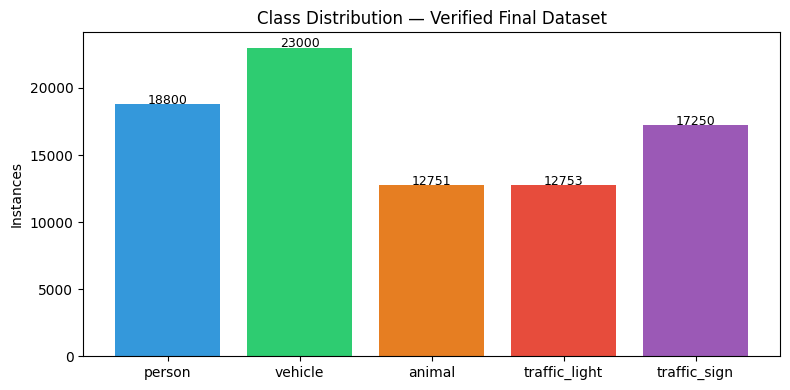

In [10]:
import matplotlib.pyplot as plt
import shutil

# Reset generated dataset (pool + final + temp) to avoid stale files from previous runs
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR, ignore_errors=True)

for base in ('pool', 'final', 'tmp'):
    for split in ('train', 'val'):
        img_dir, lbl_dir = split_dirs(split=split, base=('final' if base == 'final' else base))
        img_dir.mkdir(parents=True, exist_ok=True)
        lbl_dir.mkdir(parents=True, exist_ok=True)

# Run all parsers (write into pool)
process_bdd(limit=LIMITS['bdd'], val_ratio=VAL_RATIO)
process_lisa(limit=LIMITS['lisa'], val_ratio=VAL_RATIO)
process_idd(limit=LIMITS['idd'], val_ratio=VAL_RATIO)
process_catdog(limit=LIMITS['catdog'], val_ratio=VAL_RATIO)
process_counting(limit=LIMITS['counting'], val_ratio=VAL_RATIO)

# Clean and normalize generated labels in pool before balancing
for split in ('train', 'val'):
    stats = cleanup_generated_labels(split=split, remove_empty=True, base='pool')
    print(f"  [cleanup:pool/{split}] files={stats['files']} fixed={stats['fixed_boxes']} dropped_boxes={stats['dropped_boxes']} removed_empty={stats['removed_files']}")

# Build balanced final dataset from pool (multi-label preserved)
train_balance = rebalance_train_labels_multilabel(targets=TRAIN_TARGETS, seed=SEED, tolerance=TARGET_TOLERANCE, hard_cap=HARD_CAP_BALANCE, source_caps={'pseudo_animal_frac': PSEUDO_ANIMAL_MAX_FRAC}, source_penalty=True)
val_balance = rebalance_val_labels_multilabel(targets=VAL_TARGETS, seed=SEED, tolerance=TARGET_TOLERANCE, hard_cap=HARD_CAP_BALANCE, source_caps={'pseudo_animal_frac': PSEUDO_ANIMAL_MAX_FRAC}, source_penalty=True)

# Strict final quality gate (quarantine invalids)
val_train = validate_final_labels(split='train', strict=True, quarantine=True)
val_val = validate_final_labels(split='val', strict=True, quarantine=True)
print(f"[validate:train] invalid_rate={val_train['invalid_rate']:.4f} invalid_lines={val_train['invalid_lines']} quarantined_files={val_train['quarantined_files']}")
print(f"[validate:val]   invalid_rate={val_val['invalid_rate']:.4f} invalid_lines={val_val['invalid_lines']} quarantined_files={val_val['quarantined_files']}")
summarize_invalid_by_source(val_train, split='train')
summarize_invalid_by_source(val_val, split='val')

if val_train['invalid_rate'] > MAX_INVALID_LABEL_RATE or val_val['invalid_rate'] > MAX_INVALID_LABEL_RATE:
    offenders = (val_train.get('offenders', []) + val_val.get('offenders', []))[:20]
    print('Top offenders:')
    for o in offenders:
        print('  -', o)
    raise RuntimeError(f"Invalid label rate above threshold {MAX_INVALID_LABEL_RATE:.2%}. Please inspect quarantine files.")

# Add true no-label BDD backgrounds directly into final images split
bg_train = {'added': 0, 'requested': 0, 'manifest': None}
bg_val = {'added': 0, 'requested': 0, 'manifest': None}
if ENABLE_BDD_BACKGROUNDS:
    # Prefer IDD negatives (user-requested), then backfill from BDD if needed.
    bg_needed_total = int(BDD_BG_LIMITS['train']) + int(BDD_BG_LIMITS['val'])
    idd_bg_candidates = collect_idd_background_candidates()
    bg_candidates = list(idd_bg_candidates)
    if len(bg_candidates) < bg_needed_total:
        print(f"[bg] IDD candidates short ({len(bg_candidates)}/{bg_needed_total}); trying BDD fallback...")
        bdd_bg_candidates = collect_bdd_background_candidates()
        seen = {str(p[0]) for p in bg_candidates}
        for src, rel_name in bdd_bg_candidates:
            key = str(src)
            if key in seen:
                continue
            bg_candidates.append((src, rel_name))
            seen.add(key)

    bg_train = add_bdd_backgrounds_to_final(
        bg_candidates, split='train', limit=BDD_BG_LIMITS['train'], val_ratio=VAL_RATIO
    )
    bg_val = add_bdd_backgrounds_to_final(
        bg_candidates, split='val', limit=BDD_BG_LIMITS['val'], val_ratio=VAL_RATIO
    )
    if ENABLE_BG_MASK_FALLBACK:
        train_need = int(BDD_BG_LIMITS['train']) - int(bg_train['added'])
        val_need = int(BDD_BG_LIMITS['val']) - int(bg_val['added'])
        if train_need > 0:
            print(f"[bg] strict train short by {train_need}; filling with BDD mask fallback")
            bg_train_fill = add_bdd_masked_backgrounds_to_final(split='train', limit=train_need, val_ratio=VAL_RATIO)
            bg_train['added'] = int(bg_train['added']) + int(bg_train_fill.get('added', 0))
            bg_train['manifest'] = bg_train_fill.get('manifest', bg_train.get('manifest'))
        if val_need > 0:
            print(f"[bg] strict val short by {val_need}; filling with BDD mask fallback")
            bg_val_fill = add_bdd_masked_backgrounds_to_final(split='val', limit=val_need, val_ratio=VAL_RATIO)
            bg_val['added'] = int(bg_val['added']) + int(bg_val_fill.get('added', 0))
            bg_val['manifest'] = bg_val_fill.get('manifest', bg_val.get('manifest'))
    min_train_req = int(MIN_BG_LIMITS.get('train', BDD_BG_LIMITS['train']))
    min_val_req = int(MIN_BG_LIMITS.get('val', BDD_BG_LIMITS['val']))
    if int(bg_train['added']) < min_train_req:
        raise RuntimeError(f"train background ingest below minimum: need >= {min_train_req}, got {bg_train['added']}")
    if int(bg_val['added']) < min_val_req:
        raise RuntimeError(f"val background ingest below minimum: need >= {min_val_req}, got {bg_val['added']}")
    if int(bg_train['added']) < int(BDD_BG_LIMITS['train']) or int(bg_val['added']) < int(BDD_BG_LIMITS['val']):
        print(f"[bg] WARN added below requested limits: train={bg_train['added']}/{BDD_BG_LIMITS['train']} val={bg_val['added']}/{BDD_BG_LIMITS['val']}")
    if (not bg_train.get('manifest')) or (not bg_val.get('manifest')) or (not Path(bg_train['manifest']).exists()) or (not Path(bg_val['manifest']).exists()):
        raise RuntimeError('Background manifest files were not created as expected.')

print('\n' + '=' * 55 + '\nDATASET SUMMARY (FINAL COUNT)\n' + '=' * 55)
print(f"Pseudo-animal share train={train_balance.get('pseudo_animal_ratio',0):.3f} (cap={train_balance.get('pseudo_cap', PSEUDO_ANIMAL_MAX_FRAC):.2f})")
print(f"Pseudo-animal share val  ={val_balance.get('pseudo_animal_ratio',0):.3f} (cap={val_balance.get('pseudo_cap', PSEUDO_ANIMAL_MAX_FRAC):.2f})")

# Recalculate counts from FINAL generated labels
counts = {i: 0 for i in range(5)}
val_counts = {i: 0 for i in range(5)}

for split, bucket in [('train', counts), ('val', val_counts)]:
    label_path = OUTPUT_DIR / f'labels/{split}'
    for lf in label_path.glob('*.txt'):
        content = lf.read_text().strip()
        for line in content.splitlines():
            parts = line.split()
            if parts:
                try:
                    cls_idx = int(float(parts[0]))
                    if cls_idx in bucket:
                        bucket[cls_idx] += 1
                except ValueError:
                    pass

for split in ('train', 'val'):
    imgs = list((OUTPUT_DIR / f'images/{split}').glob('*'))
    lbls = list((OUTPUT_DIR / f'labels/{split}').glob('*.txt'))
    background_count = len(imgs) - len(lbls)
    print(f'  {split:5s}: {len(imgs):5d} images  |  {len(lbls):5d} label files  |  {background_count:5d} backgrounds')
    if ENABLE_BDD_BACKGROUNDS and split == 'train' and background_count < int(MIN_BG_LIMITS.get('train', BDD_BG_LIMITS['train'])):
        raise RuntimeError(f"train background_count below minimum: need >= {int(MIN_BG_LIMITS.get('train', BDD_BG_LIMITS['train']))}, got {background_count}")
    if ENABLE_BDD_BACKGROUNDS and split == 'val' and background_count < int(MIN_BG_LIMITS.get('val', BDD_BG_LIMITS['val'])):
        raise RuntimeError(f"val background_count below minimum: need >= {int(MIN_BG_LIMITS.get('val', BDD_BG_LIMITS['val']))}, got {background_count}")

train_min, train_max = _target_bounds(TRAIN_TARGETS, TARGET_TOLERANCE)
val_min, val_max = _target_bounds(VAL_TARGETS, TARGET_TOLERANCE)

print('\nExpected targets + bounds:')
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:14s}: train={TRAIN_TARGETS[i]:4d} [{train_min[i]}..{train_max[i]}] | val={VAL_TARGETS[i]:4d} [{val_min[i]}..{val_max[i]}]")

print('\nClass distribution (train labels):')
for i, name in enumerate(CLASS_NAMES):
    bar = '█' * (counts[i] // 300) if counts[i] > 0 else ''
    status = ' ❌ STILL 0' if counts[i] == 0 else ''
    print(f'  Class {i} ({name:14s}): {counts[i]:6d}  {bar}{status}')

print('\nTarget check (bounded multi-label):')
for i, name in enumerate(CLASS_NAMES):
    tr_ok = 'PASS' if train_min[i] <= counts[i] <= train_max[i] else 'WARN'
    va_ok = 'PASS' if val_min[i] <= val_counts[i] <= val_max[i] else 'WARN'
    print(f"  {name:14s}: train={counts[i]} / {TRAIN_TARGETS[i]} [{train_min[i]}..{train_max[i]}] [{tr_ok}] | val={val_counts[i]} / {VAL_TARGETS[i]} [{val_min[i]}..{val_max[i]}] [{va_ok}]")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6']
vals = [counts[i] for i in range(5)]
ax.bar(CLASS_NAMES, vals, color=colors)
ax.set_ylabel('Instances')
ax.set_title('Class Distribution — Verified Final Dataset')
for i, v in enumerate(vals):
    ax.text(i, v + 20, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()
print('=' * 55)


---
## 8 — Write data.yaml

In [11]:
yaml_content = f"""# Hybrid Road Detection Dataset
path: {os.path.abspath('final_hybrid_dataset')}
train: images/train
val:   images/val
nc: 5
names: ['person', 'vehicle', 'animal', 'traffic_light', 'traffic_sign']
"""
with open('data.yaml','w') as f: f.write(yaml_content)
print('✅ data.yaml written:')
print(yaml_content)

✅ data.yaml written:
# Hybrid Road Detection Dataset
path: /content/final_hybrid_dataset
train: images/train
val:   images/val
nc: 5
names: ['person', 'vehicle', 'animal', 'traffic_light', 'traffic_sign']



---
## 9 — Train YOLO26s (Single-Phase v17)

**Why YOLO26s over YOLO11s?**

YOLO26 removes DFL entirely, simplifying inference and broadening support for edge and low-power devices, and runs up to 43% faster on CPUs.

| Feature | YOLO11s | YOLO26s |
|---------|---------|---------|
| mAP@0.5 | 47.0 | **47.8** |
| CPU ONNX speed | ~80 ms | ~87 ms |
| NMS required | Yes (post-processing step) | **No — end-to-end** |
| DFL | Yes | **Removed** (simpler export) |
| Small-object accuracy | Good | **Better (STAL loss)** |
| ONNX export complexity | Standard | **Simpler (no NMS node)** |

The NMS-free design is especially valuable for CPU deployment: no separate post-processing step  
means the ONNX graph is smaller and runs faster on laptops and edge devices.

**v17 training strategy (single phase):**
- **One phase (120 epochs):** clean data + built-in dynamic augmentations
- No second fine-tuning phase and no heavy-copy regeneration step

`cos_lr=True` provides smooth learning-rate decay through the single run.


In [12]:

import os as _os
from pathlib import Path

# ── Single-phase training (v17 default) ───────────────────────────
print('=' * 60)
print('TRAINING — Single phase, 120 epochs')
print('Model: YOLO26s | cls=1.5, multi_scale, AdamW')
print('=' * 60)

# Final safety cleanup + validation before training
for split in ('train', 'val'):
    stats = cleanup_generated_labels(split=split, remove_empty=True, base='final')
    print(f"[Pre-train cleanup] {split}: fixed={stats['fixed_boxes']} dropped={stats['dropped_boxes']} removed_empty={stats['removed_files']}")

for split in ('train', 'val'):
    vstats = validate_final_labels(split=split, strict=True, quarantine=True)
    print(f"[Pre-train validate] {split}: invalid_rate={vstats['invalid_rate']:.4f} invalid_lines={vstats['invalid_lines']} quarantined={vstats['quarantined_files']}")
    summarize_invalid_by_source(vstats, split=split)


for split in ('train', 'val'):
    istats = prune_invalid_final_images(split=split, min_side=8)
    print(f"[Pre-train image sanity] {split}: checked={istats['checked']} removed={istats['removed']} unreadable={istats['unreadable']} tiny={istats['tiny']}")

for split in ('train', 'val'):
    img_dir, _ = split_dirs(split=split, base='final')
    n_images = sum(1 for p in img_dir.glob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.webp'})
    if n_images == 0:
        raise RuntimeError(f"No training images left in final/{split} after sanity cleanup.")

# Remove stale Ultralytics cache files so shape metadata is rebuilt from current images
for cache_path in (OUTPUT_DIR / 'labels' / 'train.cache', OUTPUT_DIR / 'labels' / 'val.cache'):
    if cache_path.exists():
        cache_path.unlink()
        print(f"[Pre-train cache] removed stale cache: {cache_path}")

model = YOLO('yolo26s.pt')


train_kwargs = dict(
    data        = 'data.yaml',
    epochs      = 120,
    imgsz       = 960,
    batch       = TRAIN_BATCH,
    device      = device,
    workers     = 12,
    cache       = 'disk',
    compile     = False,
    optimizer   = 'AdamW',
    lr0         = 0.002,
    lrf         = 0.01,
    momentum    = 0.937,
    weight_decay= 0.001,
    cls         = 1.5,
    warmup_epochs = 5,
    cos_lr      = True,
    hsv_h=0.015, hsv_s=0.4, hsv_v=0.3,
    degrees=5.0, translate=0.1, scale=0.50,
    fliplr=0.5, mosaic=1.0, mixup=0.15, copy_paste=0.1, close_mosaic=20,
    multi_scale = TRAIN_MULTI_SCALE,
    patience    = 50,
    save        = True,
    save_period = 10,
    project     = 'road_detector',
    name        = 'hybrid_v17',
    plots       = True,
    tracker     = TRACKER_DEFAULT,
    val         = True,
)


try:
    results = model.train(**train_kwargs)
except ZeroDivisionError as e:
    if bool(train_kwargs.get('multi_scale', False)):
        print("[train] WARN ZeroDivisionError during multi-scale resize. Retrying once with multi_scale=False.")
        print(f"[train] Cause: {e}")
        train_kwargs['multi_scale'] = False
        results = model.train(**train_kwargs)
    else:
        raise

print('\n✅ Training complete')
BEST_WEIGHTS = str(Path(results.save_dir) / 'weights' / 'best.pt')
print(f'   Best weights: {BEST_WEIGHTS}')


TRAINING — Single phase, 120 epochs
Model: YOLO26s | cls=1.5, multi_scale, AdamW
[Pre-train cleanup] train: fixed=0 dropped=0 removed_empty=0
[Pre-train cleanup] val: fixed=0 dropped=0 removed_empty=0
[Pre-train validate] train: invalid_rate=0.0000 invalid_lines=0 quarantined=0
[validate:train] invalid by source:
[validate:train] invalid by class:
[Pre-train validate] val: invalid_rate=0.0000 invalid_lines=0 quarantined=0
[validate:val] invalid by source:
[validate:val] invalid by class:
[Pre-train image sanity] train: checked=3145 removed=0 unreadable=0 tiny=0
[Pre-train image sanity] val: checked=788 removed=0 unreadable=0 tiny=0
Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (NVIDIA RTX PRO 6000 Blackwell Server Edition, 97250MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=20, cls=1.5, compile=False, conf=None, copy_paste=0.1, copy_paste_

In [14]:
import os
from pathlib import Path
from collections import Counter

def check_dataset_integrity(split='train'):
    label_dir = Path(f'final_hybrid_dataset/labels/{split}')
    if not label_dir.exists():
        print(f"❌ {split} directory not found!")
        return

    all_indices = []
    file_count = 0
    for lbl_file in label_dir.glob('*.txt'):
        file_count += 1
        with open(lbl_file, 'r') as f:
            for line in f:
                parts = line.split()
                if parts:
                    try:
                        val = int(float(parts[0]))
                        all_indices.append(val)
                    except (ValueError, IndexError):
                        continue

    counts = Counter(all_indices)
    print(f"--- {split.upper()} SET ---")
    print(f"Found {file_count} label files")
    for i in range(5):
        name = ['person', 'vehicle', 'animal', 'traffic_light', 'traffic_sign'][i]
        print(f"  Class {i} ({name:14s}): {counts.get(i, 0)}")

print("Checking both sets...")
check_dataset_integrity('train')
print()
check_dataset_integrity('val')


Checking both sets...
--- TRAIN SET ---
Found 2945 label files
  Class 0 (person        ): 18800
  Class 1 (vehicle       ): 23000
  Class 2 (animal        ): 12751
  Class 3 (traffic_light ): 12753
  Class 4 (traffic_sign  ): 17250

--- VAL SET ---
Found 758 label files
  Class 0 (person        ): 3410
  Class 1 (vehicle       ): 4600
  Class 2 (animal        ): 2552
  Class 3 (traffic_light ): 2552
  Class 4 (traffic_sign  ): 3450


---
## 10 — Robustness Evaluation

In [15]:

VAL_IMG_DIR=OUTPUT_DIR/'images/val'; VAL_LBL_DIR=OUTPUT_DIR/'labels/val'
BG_VAL_MANIFEST=OUTPUT_DIR/'background_manifest_val.csv'
REPORT_DIR=Path('robustness_report'); REPORT_DIR.mkdir(exist_ok=True)
CONF_THRESH=0.20; IOU_THRESH=0.5
eval_model=YOLO(BEST_WEIGHTS)

def apply_fog(img,intensity=0.4):
    return cv2.addWeighted(img,1-intensity,np.ones_like(img,dtype=np.uint8)*240,intensity,0)
def apply_night(img,gamma=2.5):
    table=np.array([(i/255.0)**(1/gamma)*255 for i in range(256)],dtype=np.uint8)
    return cv2.LUT(img,table)
def apply_rain(img,num_drops=800):
    out=img.copy(); h,w=out.shape[:2]
    for _ in range(num_drops):
        x1=np.random.randint(0,w); y1=np.random.randint(0,h)
        cv2.line(out,(x1,y1),(min(w-1,x1+np.random.randint(-4,4)),min(h-1,y1+np.random.randint(10,25))),(200,200,220),1,cv2.LINE_AA)
    return cv2.GaussianBlur(out,(3,3),0)
def apply_motion_blur(img,k=15):
    kernel=np.zeros((k,k)); kernel[k//2,:]=1.0/k; return cv2.filter2D(img,-1,kernel)
def apply_noise(img,sigma=25):
    return np.clip(img.astype(np.int16)+np.random.normal(0,sigma,img.shape).astype(np.int16),0,255).astype(np.uint8)
def apply_overexposure(img,factor=1.8):
    return np.clip(img.astype(np.float32)*factor,0,255).astype(np.uint8)

CORRUPTIONS={'clean':lambda img:img,'fog':apply_fog,'night':apply_night,
             'rain':apply_rain,'motion_blur':apply_motion_blur,
             'noise':apply_noise,'overexposure':apply_overexposure}

def load_gt(p,iw,ih):
    if not p.exists(): return []
    res=[]
    for line in p.read_text().splitlines():
        pts=line.strip().split()
        if len(pts)!=5: continue
        cls=int(pts[0]); cx,cy,w,h=map(float,pts[1:])
        res.append((cls,(cx-w/2)*iw,(cy-h/2)*ih,(cx+w/2)*iw,(cy+h/2)*ih))
    return res

def load_gt_classes_only(label_path):
    if not label_path.exists():
        return set()
    classes=set()
    for line in label_path.read_text().splitlines():
        parts=line.strip().split()
        if len(parts) < 1:
            continue
        try:
            cls=int(float(parts[0]))
        except ValueError:
            continue
        if 0 <= cls < len(CLASS_NAMES):
            classes.add(cls)
    return classes

def sample_eval_images(img_paths, mode='stratified', max_images=None, per_class_n=80):
    img_paths = sorted(img_paths)
    if mode == 'full':
        if max_images is None:
            return img_paths
        return img_paths[:int(max_images)]

    rng = random.Random(SEED)
    by_class = {i: [] for i in range(len(CLASS_NAMES))}
    for p in img_paths:
        classes = load_gt_classes_only(VAL_LBL_DIR / f'{p.stem}.txt')
        for cls in classes:
            by_class[cls].append(p)

    selected=[]
    for cls, plist in by_class.items():
        if not plist:
            continue
        rng.shuffle(plist)
        selected.extend(plist[:per_class_n])

    selected = sorted(set(selected))
    if max_images is not None and len(selected) > int(max_images):
        rng.shuffle(selected)
        selected = selected[:int(max_images)]
    return sorted(selected)

def iou(a,b):
    inter=max(0,min(a[2],b[2])-max(a[0],b[0]))*max(0,min(a[3],b[3])-max(a[1],b[1]))
    if inter==0: return 0.0
    return inter/((a[2]-a[0])*(a[3]-a[1])+(b[2]-b[0])*(b[3]-b[1])-inter)

def compute_metrics(preds,gts,conf_threshold=0.30):
    preds=[p for p in preds if p[1] >= conf_threshold]
    pc={i:{'tp':0,'fp':0,'fn':0} for i in range(5)}; matched=set()
    for p_cls,_,px1,py1,px2,py2 in sorted(preds,key=lambda x:-x[1]):
        best_iou,best_gi=0,-1
        for gi,(g_cls,gx1,gy1,gx2,gy2) in enumerate(gts):
            if gi in matched or g_cls!=p_cls: continue
            ov=iou([px1,py1,px2,py2],[gx1,gy1,gx2,gy2])
            if ov>best_iou: best_iou,best_gi=ov,gi
        if best_iou>=IOU_THRESH and best_gi>=0: pc[p_cls]['tp']+=1; matched.add(best_gi)
        else: pc[p_cls]['fp']+=1
    for gi,gt in enumerate(gts):
        if gi not in matched: pc[gt[0]]['fn']+=1
    return pc

def aggregate(all_pc):
    totals={i:{'tp':0,'fp':0,'fn':0} for i in range(5)}
    for pc in all_pc:
        for cls,v in pc.items():
            for k in v: totals[cls][k]+=v[k]
    result={}
    class_metrics=[]
    for cls,v in totals.items():
        tp,fp,fn=v['tp'],v['fp'],v['fn']
        p=tp/(tp+fp) if (tp+fp)>0 else 0.0
        r=tp/(tp+fn) if (tp+fn)>0 else 0.0
        f1=2*p*r/(p+r) if (p+r)>0 else 0.0
        result[CLASS_NAMES[cls]]={'precision':p,'recall':r,'f1':f1,'tp':tp,'fp':fp,'fn':fn}
        class_metrics.append((p,r,f1))
    result['MACRO_AVG']={
        'precision':float(np.mean([m[0] for m in class_metrics])),
        'recall':float(np.mean([m[1] for m in class_metrics])),
        'f1':float(np.mean([m[2] for m in class_metrics])),
    }
    return result

def apply_class_thresholds(preds, class_conf, floor_conf=0.15):
    """Filter predictions using per-class confidence thresholds with a floor."""
    filtered=[]
    for p in preds:
        cls=int(p[0]); conf=float(p[1])
        cname = CLASS_NAMES[cls] if 0 <= cls < len(CLASS_NAMES) else None
        cls_thr = float(class_conf.get(cname, floor_conf)) if cname is not None else float(floor_conf)
        thr = max(float(floor_conf), cls_thr)
        if conf >= thr:
            filtered.append(p)
    return filtered

def track_with_defaults(source, model_path, conf=0.15, tracker=TRACKER_DEFAULT, imgsz=TRACK_IMGSZ_DEFAULT, iou=0.5, classes=None, persist=True, device=device, **kwargs):
    """Run detection+tracking with low-confidence rescue defaults and ByteTrack."""
    model = YOLO(str(model_path))
    return model.track(
        source=source,
        conf=conf,
        iou=iou,
        imgsz=imgsz,
        tracker=tracker,
        classes=classes,
        persist=persist,
        device=device,
        verbose=False,
        **kwargs,
    )

def evaluate_background_fp(model, manifest_path=BG_VAL_MANIFEST, imgsz=EVAL_IMGSZ_DEFAULT, class_conf=None, floor_conf=GLOBAL_CONF_FLOOR):
    """Evaluate false positives on unlabeled background images and save CSV report."""
    manifest_path = Path(manifest_path)
    if class_conf is None:
        class_conf = CLASS_CONF
    if not manifest_path.exists():
        print(f"[bg-fp] manifest not found: {manifest_path}")
        return {}

    bg_df = pd.read_csv(manifest_path)
    if len(bg_df) == 0:
        print(f"[bg-fp] manifest is empty: {manifest_path}")
        return {}

    cls_counts = {name: 0 for name in CLASS_NAMES}
    total_dets = 0
    evaluated = 0

    for row in tqdm(bg_df.to_dict('records'), desc='  [bg-fp        ]', leave=True):
        img_path = Path(row.get('image_path', ''))
        if not img_path.exists():
            continue
        res = model.predict(str(img_path), imgsz=imgsz, conf=0.001, verbose=False)
        preds = [(int(b.cls[0]), float(b.conf[0]), *b.xyxy[0].tolist()) for r in res for b in r.boxes]
        preds = apply_class_thresholds(preds, class_conf, floor_conf=floor_conf)
        total_dets += len(preds)
        evaluated += 1
        for p in preds:
            cls = int(p[0])
            if 0 <= cls < len(CLASS_NAMES):
                cls_counts[CLASS_NAMES[cls]] += 1

    avg_fp = (total_dets / float(evaluated)) if evaluated > 0 else 0.0
    rows = []
    for cname in CLASS_NAMES:
        rows.append({
            'metric': 'per_class_false_detections_per_image',
            'class': cname,
            'value': (cls_counts[cname] / float(evaluated)) if evaluated > 0 else 0.0,
            'false_detections': int(cls_counts[cname]),
            'evaluated_images': int(evaluated),
        })
    rows.append({
        'metric': 'avg_detections_per_bg_image',
        'class': 'ALL',
        'value': float(avg_fp),
        'false_detections': int(total_dets),
        'evaluated_images': int(evaluated),
    })

    out_path = REPORT_DIR / 'background_fp_metrics.csv'
    pd.DataFrame(rows).to_csv(out_path, index=False)
    print(f"[bg-fp] evaluated={evaluated} avg_detections_per_bg_image={avg_fp:.4f} saved={out_path}")
    return {
        'evaluated_images': int(evaluated),
        'avg_detections_per_bg_image': float(avg_fp),
        'per_class_false_detections_per_image': {
            cname: ((cls_counts[cname] / float(evaluated)) if evaluated > 0 else 0.0)
            for cname in CLASS_NAMES
        },
        'csv': str(out_path),
    }

def fixed_confusion_from_records(records, conf_threshold=0.30):
    # rows=pred classes (+background), cols=true classes (+background)
    n = len(CLASS_NAMES)
    bg = n
    cm = np.zeros((n+1, n+1), dtype=np.int64)
    for rec in records:
        preds=[p for p in rec['preds'] if p[1] >= conf_threshold]
        gts=rec['gts']
        matched_gts=set()
        for p_cls,p_conf,px1,py1,px2,py2 in sorted(preds,key=lambda x:-x[1]):
            best_iou,best_gi=0,-1
            for gi,(g_cls,gx1,gy1,gx2,gy2) in enumerate(gts):
                if gi in matched_gts:
                    continue
                ov=iou([px1,py1,px2,py2],[gx1,gy1,gx2,gy2])
                if ov > best_iou:
                    best_iou,best_gi=ov,gi
            if best_iou >= IOU_THRESH and best_gi >= 0:
                g_cls=gts[best_gi][0]
                cm[p_cls, g_cls] += 1
                matched_gts.add(best_gi)
            else:
                cm[p_cls, bg] += 1
        for gi,gt in enumerate(gts):
            if gi not in matched_gts:
                cm[bg, gt[0]] += 1
    return cm

print('✅ Evaluation helpers ready (+ stratified sampling + class thresholds + tracking defaults + background FP eval)')


✅ Evaluation helpers ready (+ stratified sampling + class thresholds + tracking defaults + background FP eval)


In [16]:

img_paths=sorted(VAL_IMG_DIR.glob('*'))
eval_paths = sample_eval_images(
    img_paths,
    mode=ROBUST_EVAL_MODE,
    max_images=ROBUST_EVAL_MAX_IMAGES,
    per_class_n=80,
)
print(f'Evaluating {len(eval_paths)} val images across {len(CORRUPTIONS)} conditions (mode={ROBUST_EVAL_MODE})...\n')

results_by_corruption={}
clean_records=[]

for name,corrupt_fn in CORRUPTIONS.items():
    all_metrics=[]; sample_saved=False
    for img_path in tqdm(eval_paths,desc=f'  [{name:14s}]',leave=True):
        img=cv2.imread(str(img_path))
        if img is None:
            continue
        orig_h,orig_w=img.shape[:2]
        corrupted=corrupt_fn(img)
        if not sample_saved:
            cv2.imwrite(str(REPORT_DIR/f'sample_{name}.jpg'),
                        np.hstack([cv2.resize(img,(320,240)),cv2.resize(corrupted,(320,240))]))
            sample_saved=True

        # keep low conf for threshold-sweep compatibility
        res=eval_model.predict(corrupted,imgsz=640,conf=0.001,verbose=False)
        preds=[(int(b.cls[0]),float(b.conf[0]),*b.xyxy[0].tolist()) for r in res for b in r.boxes]
        gts=load_gt(VAL_LBL_DIR/(img_path.stem+'.txt'),orig_w,orig_h)

        all_metrics.append(compute_metrics(preds,gts,conf_threshold=CONF_THRESH))
        if name == 'clean':
            clean_records.append({'preds':preds,'gts':gts,'image':img_path.name})

    results_by_corruption[name]=aggregate(all_metrics)

print('\n✅ Evaluation complete')


Evaluating 346 val images across 7 conditions (mode=stratified)...



  [overexposure  ]: 100%|██████████| 346/346 [00:03<00:00, 111.81it/s]


✅ Evaluation complete


---
## 11 — Results Table & Report Charts

              macro_P  macro_R  macro_F1  person_F1  vehicle_F1  animal_F1  traffic_light_F1  traffic_sign_F1
corruption                                                                                                   
clean           0.525    0.344     0.403      0.382       0.511      0.355             0.591            0.174
fog             0.519    0.335     0.393      0.385       0.515      0.356             0.553            0.157
night           0.492    0.310     0.364      0.399       0.507      0.318             0.449            0.149
rain            0.487    0.302     0.355      0.363       0.491      0.233             0.533            0.156
motion_blur     0.602    0.151     0.225      0.215       0.369      0.117             0.359            0.067
noise           0.489    0.153     0.213      0.066       0.331      0.168             0.497            0.002
overexposure    0.513    0.310     0.366      0.375       0.494      0.283             0.537            0.141


  [bg-fp        ]: 100%|██████████| 30/30 [00:00<00:00, 106.35it/s]


[bg-fp] evaluated=30 avg_detections_per_bg_image=0.6000 saved=robustness_report/background_fp_metrics.csv

Best threshold metrics (clean):
          metric  best_threshold  best_value
        macro_f1            0.25    0.403155
       person_f1            0.20    0.382170
      vehicle_f1            0.40    0.568292
       animal_f1            0.10    0.363566
traffic_light_f1            0.25    0.590842
 traffic_sign_f1            0.20    0.173888

Updated CLASS_CONF: {'person': 0.2, 'vehicle': 0.4, 'animal': 0.1, 'traffic_light': 0.25, 'traffic_sign': 0.2}

Background FP avg detections/image: 0.6000


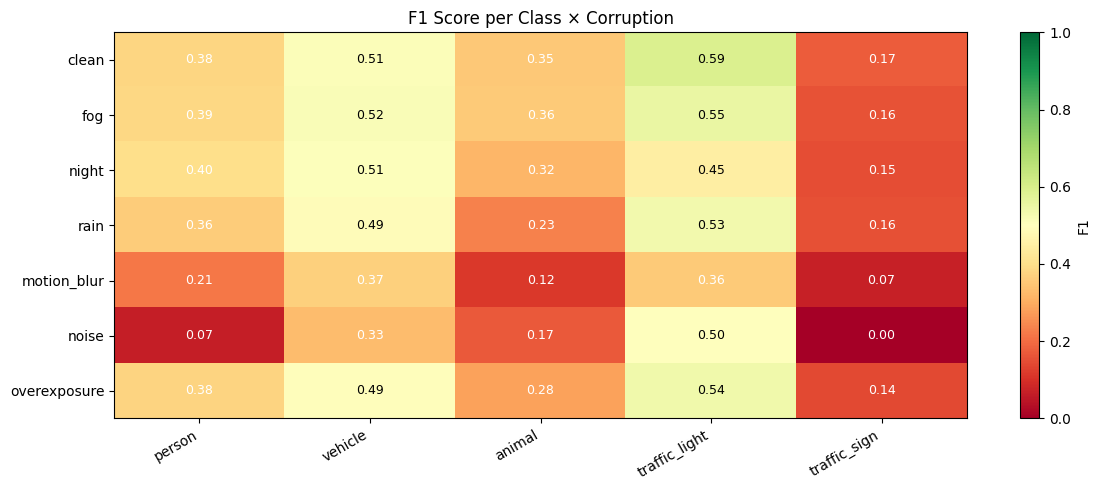

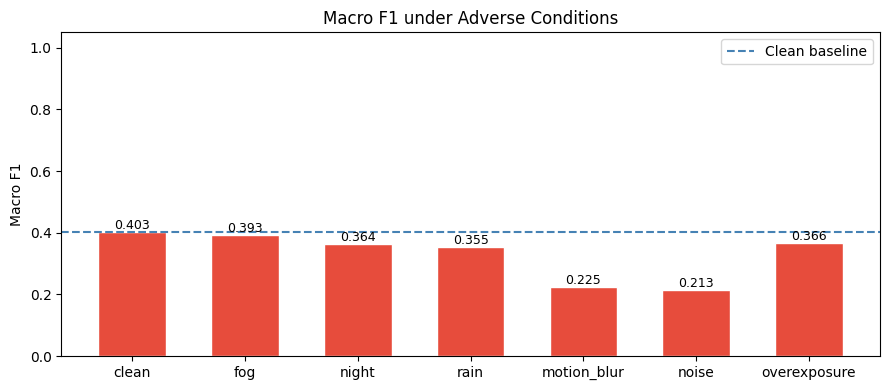

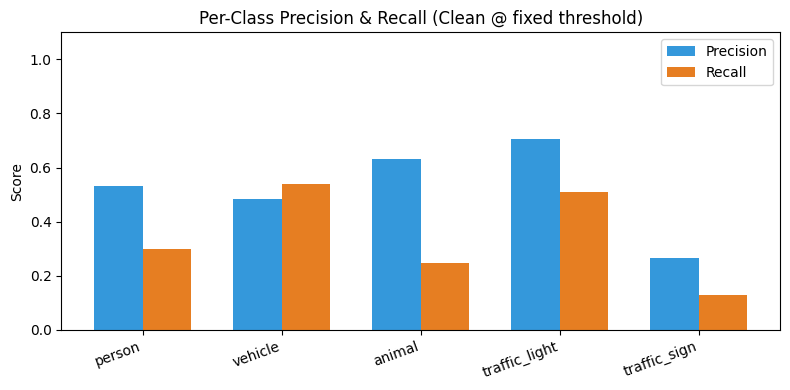


✅ Report saved to: /content/robustness_report

Note: Confusion matrix uses fixed confidence/IoU thresholds, while PR/F1-confidence curves sweep thresholds; divergence is expected.


In [17]:

import json as _json
rows=[]
for corruption,cm in results_by_corruption.items():
    macro=cm['MACRO_AVG']
    row={'corruption':corruption,'macro_P':round(macro['precision'],3),
         'macro_R':round(macro['recall'],3),'macro_F1':round(macro['f1'],3)}
    for cname in CLASS_NAMES:
        row[f'{cname}_F1']=round(cm.get(cname,{}).get('f1',0.0),3)
    rows.append(row)
df=pd.DataFrame(rows).set_index('corruption')
print(df.to_string())
df.to_csv(REPORT_DIR/'robustness_results.csv')

# Save fixed-threshold per-class confusion metrics (clean)
clean_fixed = results_by_corruption.get('clean', {})
fixed_rows=[]
for cname in CLASS_NAMES:
    m = clean_fixed.get(cname, {})
    fixed_rows.append({
        'class': cname,
        'tp': int(m.get('tp', 0)),
        'fp': int(m.get('fp', 0)),
        'fn': int(m.get('fn', 0)),
        'precision': float(m.get('precision', 0.0)),
        'recall': float(m.get('recall', 0.0)),
        'f1': float(m.get('f1', 0.0)),
    })
pd.DataFrame(fixed_rows).to_csv(REPORT_DIR/'fixed_threshold_class_metrics_clean.csv', index=False)

# Build and save fixed-threshold confusion matrix (clean)
cm_clean = fixed_confusion_from_records(clean_records, conf_threshold=CONF_THRESH)
cm_labels = CLASS_NAMES + ['background']
pd.DataFrame(cm_clean, index=[f'pred_{x}' for x in cm_labels], columns=[f'true_{x}' for x in cm_labels]).to_csv(
    REPORT_DIR/'fixed_confusion_matrix_clean.csv'
)

# Threshold sweep on clean set
sweep=[]
thresholds=np.round(np.arange(0.05, 0.96, 0.05), 2)
for thr in thresholds:
    pcs=[compute_metrics(rec['preds'], rec['gts'], conf_threshold=float(thr)) for rec in clean_records]
    agg=aggregate(pcs)
    row={'conf_threshold':float(thr),'macro_f1':float(agg['MACRO_AVG']['f1'])}
    for cname in CLASS_NAMES:
        row[f'{cname}_f1']=float(agg[cname]['f1'])
    sweep.append(row)
sweep_df=pd.DataFrame(sweep)
sweep_df.to_csv(REPORT_DIR/'threshold_sweep_clean.csv', index=False)

# Best threshold rows
best_macro_idx=sweep_df['macro_f1'].idxmax()
best_macro=sweep_df.loc[best_macro_idx]
best_rows=[{'metric':'macro_f1','best_threshold':float(best_macro['conf_threshold']),'best_value':float(best_macro['macro_f1'])}]
for cname in CLASS_NAMES:
    col=f'{cname}_f1'
    i=sweep_df[col].idxmax()
    best_rows.append({'metric':col,'best_threshold':float(sweep_df.loc[i,'conf_threshold']),'best_value':float(sweep_df.loc[i,col])})
best_df=pd.DataFrame(best_rows)
best_df.to_csv(REPORT_DIR/'best_threshold_metrics_clean.csv', index=False)

# Merge threshold sweep into runtime class thresholds with recall floor
best_thr_by_class = {}
for cname in CLASS_NAMES:
    row = best_df[best_df['metric'] == f'{cname}_f1']
    if len(row):
        best_thr_by_class[cname] = float(row.iloc[0]['best_threshold'])

for cname in CLASS_NAMES:
    cls_floor = 0.15 if cname in {'person', 'traffic_sign'} else GLOBAL_CONF_FLOOR
    sweep_thr = float(best_thr_by_class.get(cname, CLASS_CONF.get(cname, cls_floor)))
    CLASS_CONF[cname] = max(float(cls_floor), sweep_thr)

with open(REPORT_DIR/'class_conf_thresholds.json', 'w') as f:
    _json.dump(CLASS_CONF, f, indent=2)
if not (REPORT_DIR/'best_threshold_metrics_clean.csv').exists():
    raise RuntimeError('Missing threshold artifact: best_threshold_metrics_clean.csv')
if not (REPORT_DIR/'class_conf_thresholds.json').exists():
    raise RuntimeError('Missing threshold artifact: class_conf_thresholds.json')

# Additional clean metrics table using class-specific confidence thresholds
classconf_pcs=[]
for rec in clean_records:
    filtered_preds = apply_class_thresholds(rec['preds'], CLASS_CONF, floor_conf=GLOBAL_CONF_FLOOR)
    classconf_pcs.append(compute_metrics(filtered_preds, rec['gts'], conf_threshold=0.0))
classconf_clean = aggregate(classconf_pcs)
classconf_rows=[]
for cname in CLASS_NAMES:
    m = classconf_clean.get(cname, {})
    classconf_rows.append({
        'class': cname,
        'tp': int(m.get('tp', 0)),
        'fp': int(m.get('fp', 0)),
        'fn': int(m.get('fn', 0)),
        'precision': float(m.get('precision', 0.0)),
        'recall': float(m.get('recall', 0.0)),
        'f1': float(m.get('f1', 0.0)),
    })
pd.DataFrame(classconf_rows).to_csv(REPORT_DIR/'class_conf_class_metrics_clean.csv', index=False)

# Explicit false-positive check on unlabeled val backgrounds
bg_fp_summary = evaluate_background_fp(
    eval_model,
    manifest_path=BG_VAL_MANIFEST,
    imgsz=EVAL_IMGSZ_DEFAULT,
    class_conf=CLASS_CONF,
    floor_conf=GLOBAL_CONF_FLOOR,
)
print('\nBest threshold metrics (clean):')
print(best_df.to_string(index=False))
print('\nUpdated CLASS_CONF:', CLASS_CONF)
if bg_fp_summary:
    print(f"\nBackground FP avg detections/image: {bg_fp_summary['avg_detections_per_bg_image']:.4f}")

# F1 heatmap
fig,ax=plt.subplots(figsize=(12,5))
heat=df[[f'{c}_F1' for c in CLASS_NAMES]].values
im=ax.imshow(heat,aspect='auto',cmap='RdYlGn',vmin=0,vmax=1)
ax.set_xticks(range(len(CLASS_NAMES))); ax.set_xticklabels(CLASS_NAMES,rotation=30,ha='right')
ax.set_yticks(range(len(df))); ax.set_yticklabels(df.index)
for i in range(len(df)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j,i,f'{heat[i,j]:.2f}',ha='center',va='center',fontsize=9,
                color='black' if heat[i,j]>0.4 else 'white')
plt.colorbar(im,ax=ax,label='F1'); ax.set_title('F1 Score per Class × Corruption')
plt.tight_layout(); plt.savefig(REPORT_DIR/'f1_heatmap.png',dpi=150); plt.show()

# Macro F1 bar
fig,ax=plt.subplots(figsize=(9,4))
colors=['#2ecc71' if v>=0.5 else '#e74c3c' for v in df['macro_F1']]
bars=ax.bar(df.index,df['macro_F1'],color=colors,edgecolor='white',width=0.6)
ax.axhline(df.loc['clean','macro_F1'],linestyle='--',color='steelblue',linewidth=1.5,label='Clean baseline')
ax.set_ylim(0,1.05); ax.set_ylabel('Macro F1'); ax.set_title('Macro F1 under Adverse Conditions')
for bar,val in zip(bars,df['macro_F1']):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.01,f'{val:.3f}',ha='center',fontsize=9)
ax.legend(); plt.tight_layout(); plt.savefig(REPORT_DIR/'macro_f1_bar.png',dpi=150); plt.show()

# Precision-Recall clean
clean=results_by_corruption['clean']
fig,ax=plt.subplots(figsize=(8,4)); x=np.arange(len(CLASS_NAMES)); w=0.35
ax.bar(x-w/2,[clean[c]['precision'] for c in CLASS_NAMES],w,label='Precision',color='#3498db')
ax.bar(x+w/2,[clean[c]['recall']    for c in CLASS_NAMES],w,label='Recall',   color='#e67e22')
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES,rotation=20,ha='right')
ax.set_ylim(0,1.1); ax.set_ylabel('Score'); ax.set_title('Per-Class Precision & Recall (Clean @ fixed threshold)')
ax.legend(); plt.tight_layout(); plt.savefig(REPORT_DIR/'precision_recall_clean.png',dpi=150); plt.show()

def _round_nested(obj, ndigits=4):
    if isinstance(obj, dict):
        return {k: _round_nested(v, ndigits) for k, v in obj.items()}
    if isinstance(obj, list):
        return [_round_nested(v, ndigits) for v in obj]
    if isinstance(obj, (int, float, np.floating, np.integer)):
        return round(float(obj), ndigits)
    return obj

with open(REPORT_DIR/'robustness_summary.json','w') as f:
    _json.dump(_round_nested(results_by_corruption, 4), f, indent=2)
print(f'\n✅ Report saved to: {REPORT_DIR.resolve()}')
print('\nNote: Confusion matrix uses fixed confidence/IoU thresholds, while PR/F1-confidence curves sweep thresholds; divergence is expected.')


In [18]:
# Tracking helper (ByteTrack + low-confidence rescue defaults)
def run_tracking_demo(source, model_path=BEST_WEIGHTS, conf=0.15, tracker=TRACKER_DEFAULT, imgsz=TRACK_IMGSZ_DEFAULT, iou=0.5, classes=None, persist=True, device=device, **kwargs):
    return track_with_defaults(
        source=source,
        model_path=model_path,
        conf=conf,
        tracker=tracker,
        imgsz=imgsz,
        iou=iou,
        classes=classes,
        persist=persist,
        device=device,
        **kwargs,
    )

print(f"✅ Tracking helper ready: tracker={TRACKER_DEFAULT}, conf=0.15, imgsz={TRACK_IMGSZ_DEFAULT}, iou=0.5")


✅ Tracking helper ready: tracker=bytetrack.yaml, conf=0.15, imgsz=960, iou=0.5


---
## 12 — Export Best Model to ONNX (CPU Inference)

Exports YOLO26s `BEST_WEIGHTS` to ONNX.

**YOLO26s ONNX advantage:** Because YOLO26 is NMS-free (end-to-end), the exported ONNX graph  
contains no NMS post-processing node — the output is already the final set of detections.  
This makes CPU inference simpler and slightly faster than YOLO11 ONNX exports.

Typical CPU inference speed: **~87 ms/frame** (YOLO26s at 640×640 on a modern laptop, ~11 FPS).


In [19]:
best = YOLO(BEST_WEIGHTS)
best.export(format='onnx', imgsz=640, simplify=True, opset=12)

onnx_path = BEST_WEIGHTS.replace('.pt', '.onnx')
print(f'✅ ONNX export complete: {onnx_path}')
print('   CPU inference: onnxruntime — no GPU required')
print()

# ── Quick CPU inference smoke test ───────────────────────────────
try:
    import onnxruntime as ort
    import numpy as np

    sess = ort.InferenceSession(onnx_path, providers=['CPUExecutionProvider'])
    dummy = np.random.rand(1, 3, 640, 640).astype(np.float32)
    inp_name = sess.get_inputs()[0].name

    import time
    times = []
    for _ in range(5):
        t0 = time.perf_counter()
        sess.run(None, {inp_name: dummy})
        times.append((time.perf_counter() - t0) * 1000)

    print(f'CPU inference smoke test (5 runs):')
    print(f'  Mean: {sum(times)/len(times):.1f} ms  |  Min: {min(times):.1f} ms')
except ImportError:
    print('onnxruntime not installed — skipping smoke test.')
    print('Install with: pip install onnxruntime')


Ultralytics 8.4.19 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (AMD EPYC 9B45)
YOLO26s summary (fused): 122 layers, 9,467,115 parameters, 0 gradients, 20.5 GFLOPs

PyTorch: starting from '/content/runs/detect/road_detector/hybrid_v172/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (19.4 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 183ms
Prepared 4 packages in 1.61s
Installed 4 packages in 140ms
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.2
 + onnxslim==0.1.86

requirements: AutoUpdate success ✅ 2.8s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 12...
ONNX: slimming with onnxslim 0.1.86...


/usr/local/lib/python3.12/dist-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset11.py:954: UserWarning: Exporting aten::index operator of advanced indexing in opset 12 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.
  return opset9.index(g, self, index)


ONNX: export success ✅ 4.6s, saved as '/content/runs/detect/road_detector/hybrid_v172/weights/best.onnx' (36.4 MB)

Export complete (5.0s)
Results saved to /content/runs/detect/road_detector/hybrid_v172/weights
Predict:         yolo predict task=detect model=/content/runs/detect/road_detector/hybrid_v172/weights/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/content/runs/detect/road_detector/hybrid_v172/weights/best.onnx imgsz=640 data=data.yaml  
Visualize:       https://netron.app
✅ ONNX export complete: /content/runs/detect/road_detector/hybrid_v172/weights/best.onnx
   CPU inference: onnxruntime — no GPU required

CPU inference smoke test (5 runs):
  Mean: 44.0 ms  |  Min: 42.8 ms
